# Amazon Sales Data Analysis

## Project Objective

The objective of this project is to analyze Amazon sales transaction data and identify
meaningful patterns and insights related to sales, products, fulfillment, customers,
geographical distribution, and business performance.

This notebook contains the complete data analysis process, from data understanding
and cleaning to visualization and business recommendations.

## 1. Importing Required Libraries

In this section, the Python libraries required for data analysis and visualization are imported.

- Pandas is used for data manipulation and analysis.
- NumPy is used for numerical operations.
- Matplotlib is used for creating visualizations.
- Seaborn is used for statistical data visualization.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Loading the Dataset

The Amazon sales report is loaded into a Pandas DataFrame for further analysis.

The DataFrame provides a tabular structure that allows the dataset to be
examined, cleaned, analyzed, and visualized using Python.

In [4]:
df = pd.read_csv("Amazon Sale Report.csv")

## Stage 2: Data Cleaning

Data cleaning is performed to improve the quality and consistency of the dataset before
carrying out detailed analysis.

The original dataset is preserved, and a separate working copy is created so that the
original data remains unchanged.

In [5]:
df_clean = df.copy()

In [6]:
df_clean.shape

(128976, 21)

## 2.1 Removing Completely Empty Columns

Columns that contain no information in any record do not contribute to the analysis.

The completely empty columns are identified and removed from the working dataset.

In [7]:
empty_columns = df_clean.columns[df_clean.isnull().all()]

print("Completely empty columns:")
print(list(empty_columns))

Completely empty columns:
['New', 'PendingS']


In [8]:
df_clean = df_clean.drop(columns=empty_columns)

In [9]:
df_clean.shape

(128976, 19)

## 2.2 Removing Duplicate Records

The dataset is checked for completely duplicated records.

Exact duplicate rows do not provide additional information and can cause records
to be counted more than once during analysis. Therefore, exact duplicates are removed
from the working dataset.

In [10]:
duplicate_count = df_clean.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 168


In [11]:
df_clean = df_clean.drop_duplicates()

In [12]:
print("Dataset shape after removing duplicates:", df_clean.shape)

Dataset shape after removing duplicates: (128808, 19)


## 2.3 Resetting the DataFrame Index

After removing duplicate records, the DataFrame index is reset so that the cleaned
dataset has a continuous index from beginning to end.

In [13]:
df_clean = df_clean.reset_index(drop=True)

In [14]:
df_clean.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B,fulfilled-by
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,T-shirt,S,On the Way,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,False,Easy Ship
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,Shirt,3XL,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,False,Easy Ship
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Shirt,XL,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,True,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,Blazzer,L,On the Way,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,False,Easy Ship
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Trousers,3XL,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,False,NaN


## 2.4 Investigating Missing Sales Amounts

The Amount column contains missing values. Before deciding how to handle these
records, the relationship between missing Amount values and order status is examined.

This prevents important sales records from being incorrectly removed or assigned
an inappropriate value.

In [15]:
amount_missing_by_status = pd.crosstab(
    df_clean["Status"],
    df_clean["Amount"].isnull()
)

amount_missing_by_status

Amount,False,True
Status,,
Cancelled,10751,7560
Pending,656,2
Pending - Waiting for Pick Up,281,0
Shipped,77505,208
Shipped - Damaged,1,0
Shipped - Delivered to Buyer,28707,8
Shipped - Lost in Transit,5,0
Shipped - Out for Delivery,35,0
Shipped - Picked Up,973,0


In [16]:
missing_amount = df_clean["Amount"].isnull().sum()
total_records = len(df_clean)

missing_percentage = (missing_amount / total_records) * 100

print("Missing Amount values:", missing_amount)
print("Percentage missing:", round(missing_percentage, 2), "%")

Missing Amount values: 7789
Percentage missing: 6.05 %


## 2.5 Handling the Fulfilled-By Column

The fulfilled-by column contains many missing values. These missing values are
investigated in relation to the Fulfilment column.

The missing values correspond to Amazon-fulfilled orders, while Merchant-fulfilled
orders contain fulfilled-by information. Therefore, these missing values represent
the structure of the source data rather than necessarily indicating incorrect records.

The rows are retained for further analysis.

In [17]:
pd.crosstab(
    df_clean["Fulfilment"],
    df_clean["fulfilled-by"].isnull()
)

fulfilled-by,False,True
Fulfilment,,
Amazon,0,89595
Merchant,39213,0


## 2.6 Checking Missing Shipping Information

The shipping location columns are checked for missing values.

The records are examined to determine whether missing city, state, postal code,
and country information occurs in the same records.

In [18]:
location_columns = [
    "ship-city",
    "ship-state",
    "ship-postal-code",
    "ship-country"
]

df_clean[location_columns].isnull().sum()

,0
ship-city,33
ship-state,33
ship-postal-code,33
ship-country,33


In [19]:
df_clean[df_clean[location_columns].isnull().any(axis=1)][
    ["Order ID", "Status", "Amount"] + location_columns
]

,Order ID,Status,Amount,ship-city,ship-state,ship-postal-code,ship-country
1841,404-0566904-4825137,Shipped,493.0,NaN,NaN,NaN,NaN
1842,404-0566904-4825137,Shipped,458.0,NaN,NaN,NaN,NaN
8585,406-4003386-8768363,Shipped,432.0,NaN,NaN,NaN,NaN
11048,402-0107720-7057168,Shipped,654.0,NaN,NaN,NaN,NaN
13085,407-4532637-8415521,Cancelled,380.0,NaN,NaN,NaN,NaN
15521,404-9229894-8608305,Shipped,442.0,NaN,NaN,NaN,NaN
16620,402-4919636-4333150,Shipped - Delivered to Buyer,376.0,NaN,NaN,NaN,NaN
18184,405-4927647-8064368,Shipped,1112.0,NaN,NaN,NaN,NaN
22763,402-8628677-0457954,Shipped - Returned to Seller,654.0,NaN,NaN,NaN,NaN
24819,406-4079063-8291520,Cancelled,399.0,NaN,NaN,NaN,NaN


## 2.7 Checking Quantity Values

The Quantity column is checked for invalid negative values.

This ensures that the numerical data is suitable for further product and sales analysis.

In [20]:
print("Minimum Quantity:", df_clean["Qty"].min())
print("Maximum Quantity:", df_clean["Qty"].max())
print("Negative Quantity values:", (df_clean["Qty"] < 0).sum())

Minimum Quantity: 0
Maximum Quantity: 15
Negative Quantity values: 0


## 2.8 Checking Sales Amount Values

The Amount column is checked for negative values to identify potentially invalid
sales amounts.

Missing values are not modified at this stage because they have already been
investigated separately.

In [21]:
print("Minimum Amount:", df_clean["Amount"].min())
print("Maximum Amount:", df_clean["Amount"].max())
print("Negative Amount values:", (df_clean["Amount"] < 0).sum())

Minimum Amount: 0.0
Maximum Amount: 5584.0
Negative Amount values: 0


## 2.9 Final Missing Value Check

The cleaned dataset is checked again for missing values after the initial cleaning
operations.

The remaining missing values are retained where they represent meaningful or
unavoidable missing information in the original dataset.

In [22]:
df_clean.isnull().sum()

,0
index,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Category,0
Size,0
Courier Status,0


## 2.10 Cleaned Dataset Overview

The dimensions and basic structure of the cleaned dataset are checked to confirm
that the cleaning operations were applied successfully.

In [23]:
print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])
print("Duplicate rows:", df_clean.duplicated().sum())

Rows: 128808
Columns: 19
Duplicate rows: 0


## 2.11 Saving the Cleaned Dataset

The cleaned dataset is saved as a separate CSV file.

The original dataset remains unchanged, while the cleaned version will be used
for the remaining analysis stages of the project.

In [24]:
df_clean.to_csv("Amazon_Sales_Cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


# Stage 3: Sales Analysis

In this stage, the cleaned Amazon sales dataset is analyzed to understand overall
sales performance and trends.

The analysis begins with key sales metrics and then examines how sales vary over time.

## 3.1 Working with the Cleaned Dataset

The cleaned dataset is used for the sales analysis to ensure that duplicate records
and completely empty columns do not affect the results.

In [25]:
df_clean.shape

(128808, 19)

## 3.2 Total Number of Sales Records

The total number of records in the cleaned dataset is calculated to understand the
volume of transactions available for analysis.

In [26]:
total_records = len(df_clean)

print("Total number of records:", total_records)

Total number of records: 128808


## 3.3 Unique Order Count

The number of unique Order IDs is calculated to determine how many distinct orders
are represented in the dataset.

In [27]:
unique_orders = df_clean["Order ID"].nunique()

print("Number of unique orders:", unique_orders)

Number of unique orders: 120229


## 3.4 Total Sales Amount

The total sales amount is calculated using the available values in the Amount column.

Records with missing Amount values are not included in this calculation because
their sales value is unavailable in the source data.

In [28]:
total_sales = df_clean["Amount"].sum()

print("Total recorded sales amount:", round(total_sales, 2))

Total recorded sales amount: 78496786.39


## 3.5 Average Sales Amount

The average recorded sales amount is calculated to understand the typical monetary
value of a transaction with an available Amount value.

In [29]:
average_sales = df_clean["Amount"].mean()

print("Average recorded sales amount:", round(average_sales, 2))

Average recorded sales amount: 648.63


## 3.6 Sales Amount Range

The minimum and maximum recorded sales amounts are examined to understand the range
of transaction values in the dataset.

In [30]:
print("Minimum sales amount:", df_clean["Amount"].min())
print("Maximum sales amount:", df_clean["Amount"].max())

Minimum sales amount: 0.0
Maximum sales amount: 5584.0


## 3.7 Key Sales Metrics

The main sales performance metrics are summarized together to provide a quick
overview of the dataset before examining sales trends over time.

In [31]:
sales_summary = pd.DataFrame({
    "Metric": [
        "Total Records",
        "Unique Orders",
        "Total Recorded Sales",
        "Average Recorded Sales",
        "Minimum Sales Amount",
        "Maximum Sales Amount"
    ],
    "Value": [
        total_records,
        unique_orders,
        round(total_sales, 2),
        round(average_sales, 2),
        df_clean["Amount"].min(),
        df_clean["Amount"].max()
    ]
})

sales_summary

,Metric,Value
0,Total Records,128808.00
1,Unique Orders,120229.00
2,Total Recorded Sales,78496786.39
3,Average Recorded Sales,648.63
4,Minimum Sales Amount,0.00
5,Maximum Sales Amount,5584.00


## 3.8 Preparing the Date Variable for Trend Analysis

The Date column is checked to ensure that it is stored in a date format suitable
for time-based analysis.

In [32]:
df_clean["Date"] = pd.to_datetime(
    df["Date"],
    format="%m-%d-%y",
    errors="coerce"
)

df_clean["Date"].head()

,Date
0,2022-04-30
1,2022-04-30
2,2022-04-30
3,2022-04-30
4,2022-04-30


In [33]:
print("Valid dates:", df_clean["Date"].notna().sum())
print("Missing dates:", df_clean["Date"].isna().sum())

Valid dates: 73775
Missing dates: 55033


In [34]:
print("Date data type:", df_clean["Date"].dtype)
print("Missing dates:", df_clean["Date"].isnull().sum())

Date data type: datetime64[ns]
Missing dates: 55033


## 3.9 Daily Sales Analysis

The total recorded sales amount is aggregated by date to identify changes in sales
activity over the period covered by the dataset.

In [35]:
daily_sales = (
    df_clean.groupby("Date")["Amount"]
    .sum()
    .reset_index()
)

daily_sales.head()

,Date,Amount
0,2022-03-31,118025.33
1,2022-04-13,982505.23
2,2022-04-14,1106541.52
3,2022-04-15,1039467.32
4,2022-04-16,1001452.58


## 3.10 Highest Sales Day

The day with the highest recorded sales amount is identified to determine the
strongest daily sales period in the dataset.

In [36]:
highest_sales_day = daily_sales.loc[
    daily_sales["Amount"].idxmax()
]

highest_sales_day

,2
Date,2022-04-14 00:00:00
Amount,1106541.52


## 3.11 Lowest Sales Day

The day with the lowest recorded sales amount is identified to determine the
weakest daily sales period in the dataset.

In [37]:
lowest_sales_day = daily_sales.loc[
    daily_sales["Amount"].idxmin()
]

lowest_sales_day

,0
Date,2022-03-31 00:00:00
Amount,118025.33


## 3.12 Monthly Sales Analysis

Daily sales are aggregated into monthly sales to identify broader sales trends
during the period covered by the dataset.

Monthly analysis provides a clearer view of changes in sales performance over time.

In [38]:
df_clean["Month"] = df_clean["Date"].dt.to_period("M")

In [39]:
monthly_sales = (
    df_clean.groupby("Month")["Amount"]
    .sum()
    .reset_index()
)

monthly_sales

,Month,Amount
0,2022-03,118025.33
1,2022-04,17529523.99
2,2022-05,14921585.90
3,2022-06,12508410.69


## 3.13 Preparing Monthly Data for Visualization

The monthly period variable is converted into a date representation so that the
monthly sales results can be visualized correctly on a time-based chart.

In [40]:
monthly_sales["Month"] = monthly_sales["Month"].dt.to_timestamp()

monthly_sales

,Month,Amount
0,2022-03-01,118025.33
1,2022-04-01,17529523.99
2,2022-05-01,14921585.90
3,2022-06-01,12508410.69


## 3.14 Highest Sales Month

The month with the highest recorded sales amount is identified to determine the
strongest sales period in the dataset.

In [41]:
highest_sales_month = monthly_sales.loc[
    monthly_sales["Amount"].idxmax()
]

highest_sales_month

,1
Month,2022-04-01 00:00:00
Amount,17529523.99


## 3.15 Lowest Sales Month

The month with the lowest recorded sales amount is identified to determine the
weakest sales period in the dataset.

In [42]:
lowest_sales_month = monthly_sales.loc[
    monthly_sales["Amount"].idxmin()
]

lowest_sales_month

,0
Month,2022-03-01 00:00:00
Amount,118025.33


## 3.16 Monthly Sales Trend

A line chart is used to visualize the change in recorded sales amount across
the months in the dataset.

The visualization helps identify increases, decreases, and overall patterns
in sales performance over time.

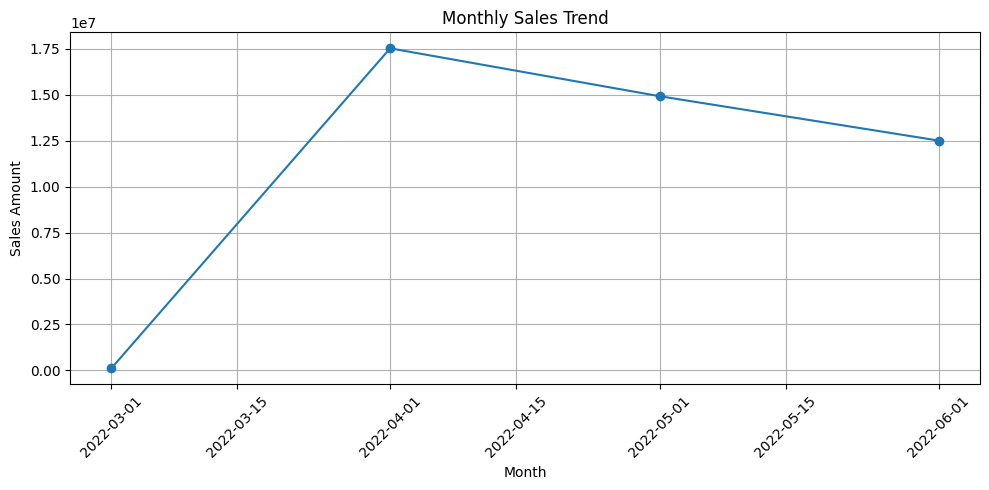

In [43]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_sales["Month"],
    monthly_sales["Amount"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales Amount")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

## 3.17 Monthly Order Volume

The number of records for each month is calculated to compare order volume with
the monthly sales amount.

This helps determine whether changes in sales are associated with changes in
the number of transactions.

In [44]:
monthly_orders = (
    df_clean.groupby(df_clean["Date"].dt.to_period("M"))
    .size()
    .reset_index(name="Order Records")
)

monthly_orders

,Date,Order Records
0,2022-03,171
1,2022-04,30114
2,2022-05,23420
3,2022-06,20070


## 3.18 Monthly Sales and Order Volume Summary

Monthly sales amount and order volume are combined into a single summary table
to support comparison between sales value and transaction activity.

In [45]:
monthly_summary = monthly_sales.copy()

monthly_summary["Month_Period"] = monthly_summary["Month"].dt.to_period("M")

monthly_summary = monthly_summary.merge(
    monthly_orders,
    left_on="Month_Period",
    right_on="Date",
    how="left"
)

monthly_summary = monthly_summary[
    ["Month", "Amount", "Order Records"]
]

monthly_summary

,Month,Amount,Order Records
0,2022-03-01,118025.33,171
1,2022-04-01,17529523.99,30114
2,2022-05-01,14921585.90,23420
3,2022-06-01,12508410.69,20070


## 3.19 Average Sales Amount per Record by Month

The average recorded sales amount per transaction is calculated for each month.

This metric helps compare transaction value independently of the total number
of records.

In [46]:
monthly_summary["Average Amount per Record"] = (
    monthly_summary["Amount"] / monthly_summary["Order Records"]
)

monthly_summary

,Month,Amount,Order Records,Average Amount per Record
0,2022-03-01,118025.33,171,690.206608
1,2022-04-01,17529523.99,30114,582.105466
2,2022-05-01,14921585.90,23420,637.130056
3,2022-06-01,12508410.69,20070,623.239197


## 3.20 Order Status Distribution

The distribution of orders across different order statuses is analyzed to understand
the overall outcome of orders in the dataset.

This helps identify the proportion of orders that were successfully shipped, delivered,
cancelled, returned, or remained pending.

In [47]:
status_counts = df_clean["Status"].value_counts()

status_counts

,count
Status,
Shipped,77713
Shipped - Delivered to Buyer,28715
Cancelled,18311
Shipped - Returned to Seller,1952
Shipped - Picked Up,973
Pending,658
Pending - Waiting for Pick Up,281
Shipped - Returning to Seller,145
Shipped - Out for Delivery,35


## 3.21 Order Status Percentage Distribution

The percentage contribution of each order status is calculated to provide a clearer
comparison between different order outcomes.

In [48]:
status_percentage = (
    df_clean["Status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

status_percentage

,proportion
Status,
Shipped,60.33
Shipped - Delivered to Buyer,22.29
Cancelled,14.22
Shipped - Returned to Seller,1.52
Shipped - Picked Up,0.76
Pending,0.51
Pending - Waiting for Pick Up,0.22
Shipped - Returning to Seller,0.11
Shipped - Out for Delivery,0.03


## 3.22 Order Status Summary

The order status counts and percentages are combined into a summary table to provide
a concise overview of order outcomes.

In [49]:
status_summary = pd.DataFrame({
    "Order Status": status_counts.index,
    "Count": status_counts.values,
    "Percentage": status_percentage.values
})

status_summary

,Order Status,Count,Percentage
0,Shipped,77713,60.33
1,Shipped - Delivered to Buyer,28715,22.29
2,Cancelled,18311,14.22
3,Shipped - Returned to Seller,1952,1.52
4,Shipped - Picked Up,973,0.76
5,Pending,658,0.51
6,Pending - Waiting for Pick Up,281,0.22
7,Shipped - Returning to Seller,145,0.11
8,Shipped - Out for Delivery,35,0.03
9,Shipped - Rejected by Buyer,11,0.01


## 3.23 Order Status Distribution Visualization

A bar chart is created to visually compare the number of records associated with
each order status.

The visualization makes the dominant and less frequent order outcomes easier to identify.

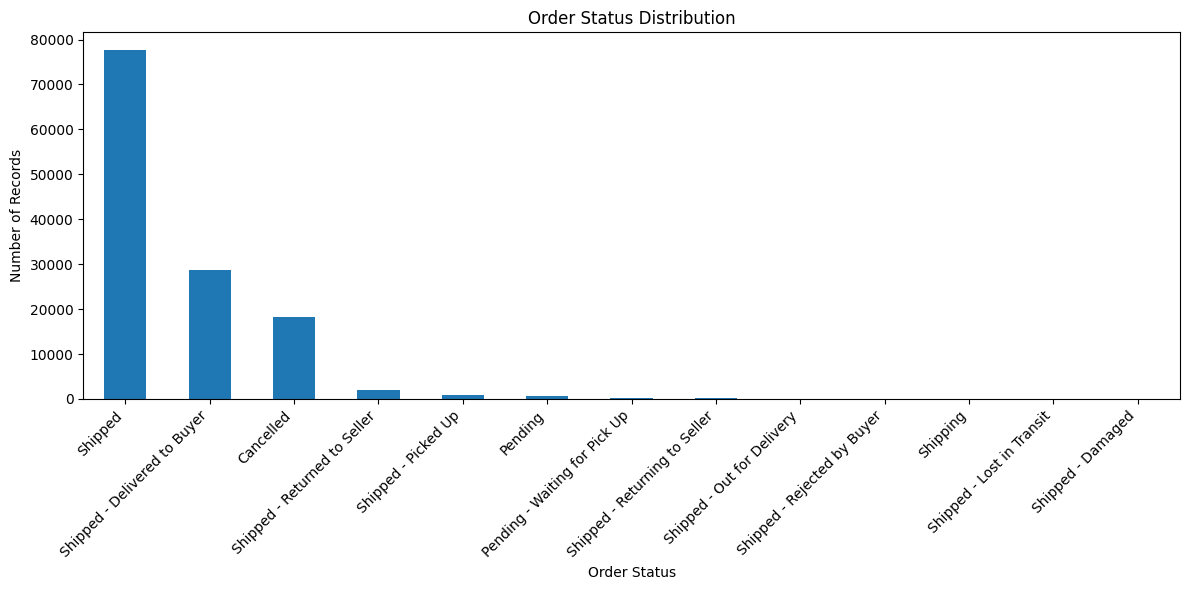

In [50]:
plt.figure(figsize=(12, 6))

status_counts.plot(kind="bar")

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Records")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## 3.24 Cancelled Order Analysis

Cancelled orders are examined separately because cancellations can have an important
impact on overall sales performance.

The number and percentage of cancelled records are calculated to understand their
relative contribution to the dataset.

In [51]:
cancelled_count = (
    df_clean["Status"]
    .str.lower()
    .eq("cancelled")
    .sum()
)

cancelled_percentage = (
    cancelled_count / len(df_clean) * 100
)

print("Cancelled records:", cancelled_count)
print("Cancelled percentage:", round(cancelled_percentage, 2), "%")

Cancelled records: 18311
Cancelled percentage: 14.22 %


## 3.25 Sales Amount Associated With Cancelled Orders

The recorded sales amount associated with cancelled orders is calculated separately.

This helps distinguish between the number of cancelled records and the monetary
value represented by those records.

In [52]:
cancelled_sales = df_clean.loc[
    df_clean["Status"].str.lower().eq("cancelled"),
    "Amount"
].sum()

print("Recorded Amount associated with cancelled orders:",
      round(cancelled_sales, 2))

Recorded Amount associated with cancelled orders: 6910831.39


## 3.26 Cancelled vs Non-Cancelled Records

The dataset is divided into cancelled and non-cancelled records to compare their
relative volumes.

This provides a broader view of the order outcome pattern.

In [53]:
cancelled_vs_non_cancelled = pd.Series({
    "Cancelled": cancelled_count,
    "Non-Cancelled": len(df_clean) - cancelled_count
})

cancelled_vs_non_cancelled

,0
Cancelled,18311
Non-Cancelled,110497


## 3.27 Cancelled vs Non-Cancelled Visualization

A bar chart is used to compare cancelled and non-cancelled records.

This provides a simple visual representation of the overall order outcome pattern.

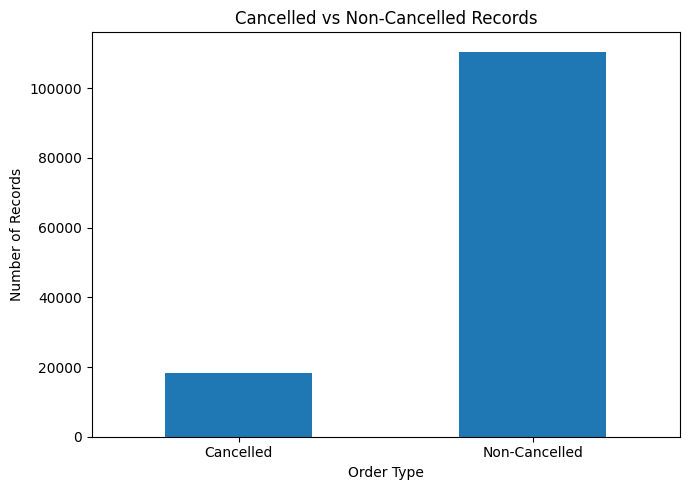

In [54]:
plt.figure(figsize=(7, 5))

cancelled_vs_non_cancelled.plot(kind="bar")

plt.title("Cancelled vs Non-Cancelled Records")
plt.xlabel("Order Type")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 3.28 Fulfillment Distribution

The distribution of records across different fulfillment methods is analyzed to
understand how orders are fulfilled in the dataset.

This provides the basis for comparing Amazon and Merchant fulfillment.

In [55]:
fulfilment_counts = df_clean["Fulfilment"].value_counts()

fulfilment_counts

,count
Fulfilment,
Amazon,89595
Merchant,39213


## 3.29 Fulfillment Percentage Distribution

The percentage contribution of each fulfillment method is calculated to compare
their relative share of the records in the dataset.

In [56]:
fulfilment_percentage = (
    df_clean["Fulfilment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

fulfilment_percentage

,proportion
Fulfilment,
Amazon,69.56
Merchant,30.44


## 3.30 Fulfillment Summary

The fulfillment counts and percentages are combined into a summary table to provide
a concise overview of the distribution of fulfillment methods.

In [57]:
fulfilment_summary = pd.DataFrame({
    "Fulfillment": fulfilment_counts.index,
    "Count": fulfilment_counts.values,
    "Percentage": fulfilment_percentage.values
})

fulfilment_summary

,Fulfillment,Count,Percentage
0,Amazon,89595,69.56
1,Merchant,39213,30.44


## 3.31 Fulfillment Distribution Visualization

A bar chart is created to visually compare the number of records handled through
each fulfillment method.

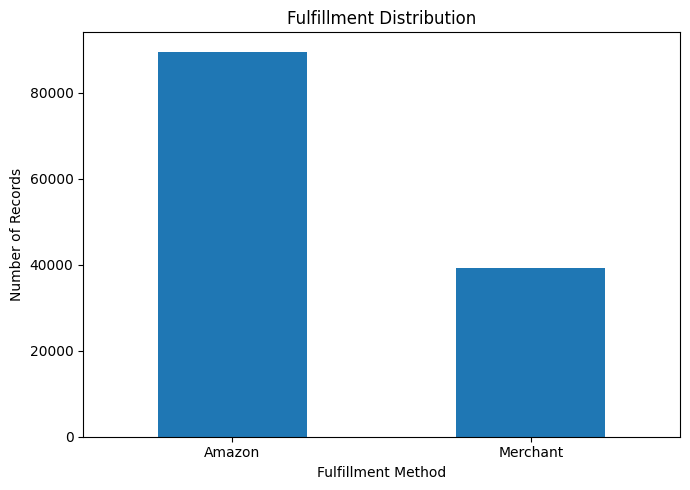

In [58]:
plt.figure(figsize=(7, 5))

fulfilment_counts.plot(kind="bar")

plt.title("Fulfillment Distribution")
plt.xlabel("Fulfillment Method")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 3.32 Order Status by Fulfillment Method

Order statuses are compared across fulfillment methods to understand whether
order outcomes differ between Amazon-fulfilled and Merchant-fulfilled records.

This provides a more meaningful comparison than simply comparing the number
of records handled by each fulfillment method.

In [59]:
fulfilment_status = pd.crosstab(
    df_clean["Fulfilment"],
    df_clean["Status"]
)

fulfilment_status

Status,Cancelled,Pending,Pending - Waiting for Pick Up,Shipped,Shipped - Damaged,Shipped - Delivered to Buyer,Shipped - Lost in Transit,Shipped - Out for Delivery,Shipped - Picked Up,Shipped - Rejected by Buyer,Shipped - Returned to Seller,Shipped - Returning to Seller,Shipping
Fulfilment,,,,,,,,,,,,,
Amazon,11459,415,0,77713,0,0,0,0,0,0,0,0,8
Merchant,6852,243,281,0,1,28715,5,35,973,11,1952,145,0


## 3.33 Order Status Percentage by Fulfillment

The percentage distribution of order statuses is calculated separately for each
fulfillment method.

Using percentages allows Amazon and Merchant fulfillment to be compared despite
their different order volumes.

In [60]:
fulfilment_status_percentage = pd.crosstab(
    df_clean["Fulfilment"],
    df_clean["Status"],
    normalize="index"
).mul(100).round(2)

fulfilment_status_percentage

Status,Cancelled,Pending,Pending - Waiting for Pick Up,Shipped,Shipped - Damaged,Shipped - Delivered to Buyer,Shipped - Lost in Transit,Shipped - Out for Delivery,Shipped - Picked Up,Shipped - Rejected by Buyer,Shipped - Returned to Seller,Shipped - Returning to Seller,Shipping
Fulfilment,,,,,,,,,,,,,
Amazon,12.79,0.46,0.00,86.74,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01
Merchant,17.47,0.62,0.72,0.00,0.0,73.23,0.01,0.09,2.48,0.03,4.98,0.37,0.00


## 3.34 Cancellation Rate by Fulfillment

The cancellation rate is calculated separately for Amazon and Merchant fulfillment.

This helps determine whether the likelihood of cancellation differs between
the two fulfillment methods.

In [61]:
cancellation_rate = (
    df_clean["Status"]
    .eq("Cancelled")
    .groupby(df_clean["Fulfilment"])
    .mean()
    .mul(100)
    .round(2)
)

cancellation_rate

,Status
Fulfilment,
Amazon,12.79
Merchant,17.47


## 3.35 Return-Related Orders by Fulfillment

Return-related order statuses are identified and compared across fulfillment
methods.

The analysis combines orders that have been returned or are in the process
of being returned to the seller.

In [62]:
return_statuses = [
    "Shipped - Returned to Seller",
    "Shipped - Returning to Seller"
]

return_rate = (
    df_clean["Status"]
    .isin(return_statuses)
    .groupby(df_clean["Fulfilment"])
    .mean()
    .mul(100)
    .round(2)
)

return_rate

,Status
Fulfilment,
Amazon,0.00
Merchant,5.35


## 3.36 Fulfillment Performance Summary

Key fulfillment performance indicators are combined into a summary table.

The table includes record volume, cancellation rate, and return-related order rate
for each fulfillment method.

In [63]:
fulfilment_performance = pd.DataFrame({
    "Total Records": fulfilment_counts,
    "Cancellation Rate (%)": cancellation_rate,
    "Return-Related Rate (%)": return_rate
})

fulfilment_performance

,Total Records,Cancellation Rate (%),Return-Related Rate (%)
Fulfilment,,,
Amazon,89595,12.79,0.00
Merchant,39213,17.47,5.35


## 3.37 Cancellation Rate by Fulfillment Visualization

A bar chart is used to compare cancellation rates between Amazon and Merchant
fulfillment.

Because the rates are calculated within each fulfillment group, the comparison
accounts for the different sizes of the two groups.

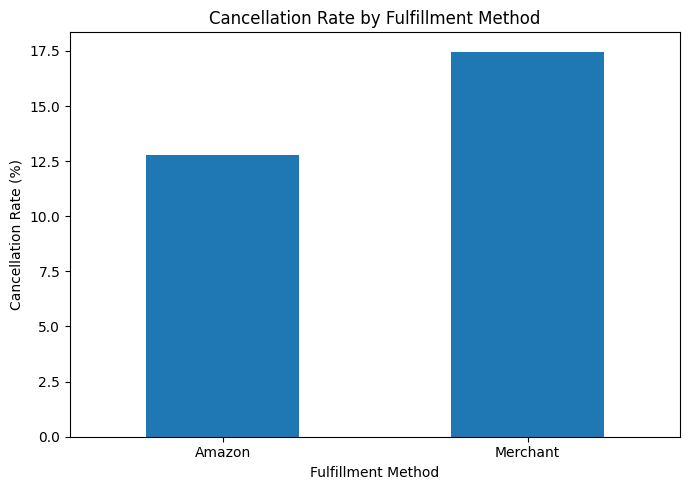

In [64]:
plt.figure(figsize=(7, 5))

cancellation_rate.plot(kind="bar")

plt.title("Cancellation Rate by Fulfillment Method")
plt.xlabel("Fulfillment Method")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 3.38 Product Category Distribution

The distribution of records across product categories is analyzed to identify
the categories with the highest order volume.

This provides an initial understanding of the product mix in the dataset.

In [65]:
category_counts = df_clean["Category"].value_counts()

category_counts

,count
Category,
T-shirt,50219
Shirt,49804
Blazzer,15489
Trousers,10607
Perfume,1157
Wallet,926
Socks,439
Shoes,164
Watch,3


## 3.39 Product Category Percentage Distribution

The percentage contribution of each product category is calculated to compare
the relative share of categories in the dataset.

In [66]:
category_percentage = (
    df_clean["Category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

category_percentage

,proportion
Category,
T-shirt,38.99
Shirt,38.67
Blazzer,12.02
Trousers,8.23
Perfume,0.90
Wallet,0.72
Socks,0.34
Shoes,0.13
Watch,0.00


## 3.40 Product Category Summary

The category counts and percentages are combined into a summary table to provide
a concise overview of the product category distribution.

In [67]:
category_summary = pd.DataFrame({
    "Category": category_counts.index,
    "Order Records": category_counts.values,
    "Percentage": category_percentage.values
})

category_summary

,Category,Order Records,Percentage
0,T-shirt,50219,38.99
1,Shirt,49804,38.67
2,Blazzer,15489,12.02
3,Trousers,10607,8.23
4,Perfume,1157,0.90
5,Wallet,926,0.72
6,Socks,439,0.34
7,Shoes,164,0.13
8,Watch,3,0.00


## 3.41 Product Category Distribution Visualization

A bar chart is used to compare the number of records across product categories.

This visualization helps identify the categories with the highest and lowest
order volumes.

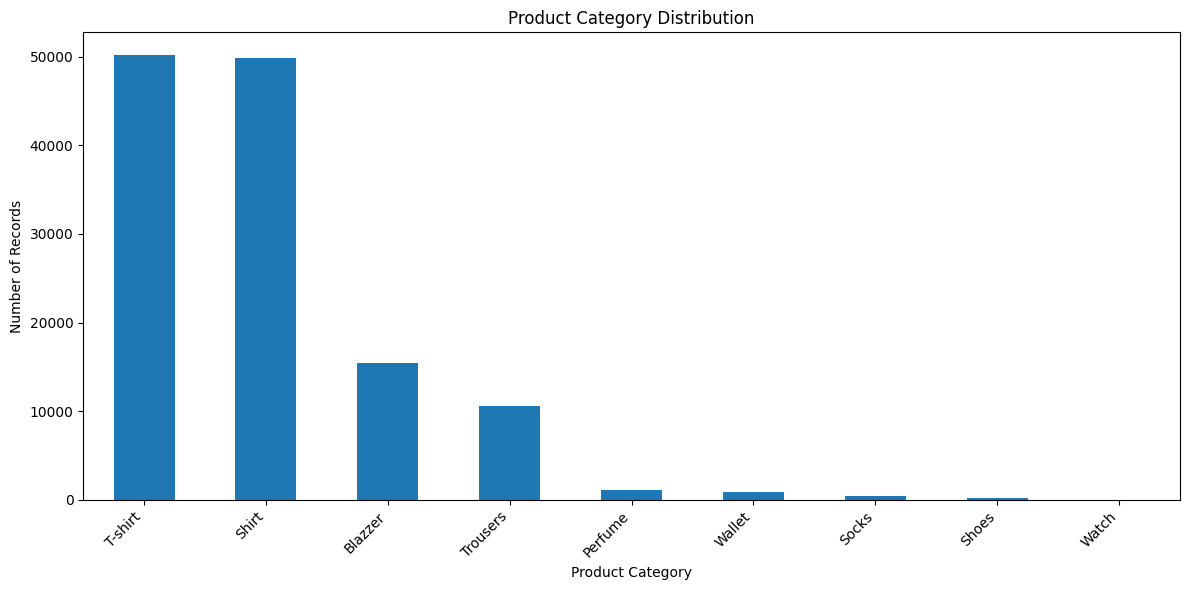

In [68]:
plt.figure(figsize=(12, 6))

category_counts.plot(kind="bar")

plt.title("Product Category Distribution")
plt.xlabel("Product Category")
plt.ylabel("Number of Records")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## 3.42 Sales Amount by Product Category

The total recorded sales amount is aggregated by product category to identify
which categories contribute the greatest recorded sales value.

Records with missing Amount values are naturally excluded from the sum.

In [69]:
category_sales = (
    df_clean.groupby("Category")["Amount"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

,Amount
Category,
T-shirt,39154132.17
Shirt,21269768.70
Blazzer,11208506.12
Trousers,5341305.30
Perfume,789419.66
Wallet,458408.18
Socks,150397.50
Shoes,123933.76
Watch,915.00


## 3.43 Sales Amount by Product Category Visualization

A bar chart is created to compare the recorded sales amount generated by each
product category.

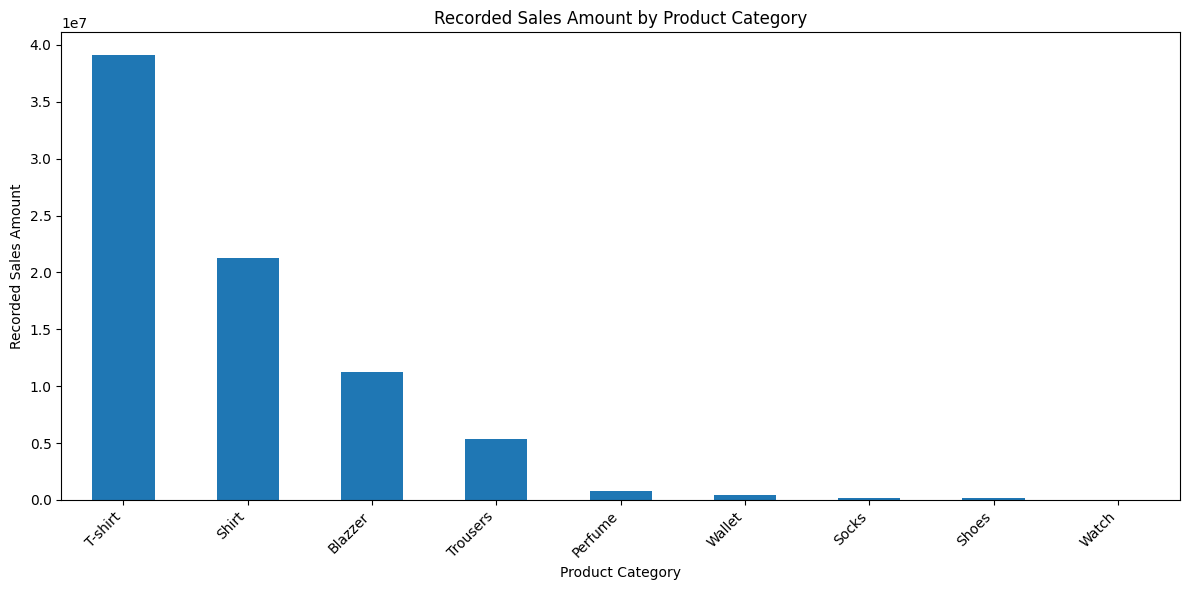

In [70]:
plt.figure(figsize=(12, 6))

category_sales.plot(kind="bar")

plt.title("Recorded Sales Amount by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Recorded Sales Amount")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## 3.44 Average Sales Amount by Product Category

The average recorded sales amount is calculated for each product category.

This helps compare the typical transaction value across categories rather than
only comparing their total sales.

In [71]:
category_average = (
    df_clean.groupby("Category")["Amount"]
    .mean()
    .sort_values(ascending=False)
)

category_average

,Amount
Category,
T-shirt,833.421289
Shoes,799.572645
Blazzer,762.794754
Perfume,723.574390
Trousers,526.185134
Wallet,520.327106
Shirt,455.992469
Socks,358.943914
Watch,305.000000


## 3.45 Product Category Performance Summary

The main category-level performance indicators are combined into a single
summary table.

This allows order volume, total recorded sales, and average recorded sales
to be compared together.

In [72]:
category_performance = pd.DataFrame({
    "Order Records": category_counts,
    "Total Recorded Sales": category_sales,
    "Average Recorded Sales": category_average
})

category_performance = category_performance.sort_values(
    "Total Recorded Sales",
    ascending=False
)

category_performance

,Order Records,Total Recorded Sales,Average Recorded Sales
Category,,,
T-shirt,50219,39154132.17,833.421289
Shirt,49804,21269768.70,455.992469
Blazzer,15489,11208506.12,762.794754
Trousers,10607,5341305.30,526.185134
Perfume,1157,789419.66,723.574390
Wallet,926,458408.18,520.327106
Socks,439,150397.50,358.943914
Shoes,164,123933.76,799.572645
Watch,3,915.00,305.000000


## 3.46 Highest-Sales Product Category

The product category with the highest recorded sales amount is identified
to determine the strongest category in terms of total recorded sales.

In [73]:
highest_sales_category = category_sales.idxmax()
highest_category_sales = category_sales.max()

print("Highest-sales category:", highest_sales_category)
print("Recorded sales amount:", round(highest_category_sales, 2))

Highest-sales category: T-shirt
Recorded sales amount: 39154132.17


## 3.47 Highest-Volume Product Category

The product category with the highest number of records is identified to
determine which category has the greatest order volume.

In [74]:
highest_volume_category = category_counts.idxmax()
highest_category_volume = category_counts.max()

print("Highest-volume category:", highest_volume_category)
print("Number of records:", highest_category_volume)

Highest-volume category: T-shirt
Number of records: 50219


## 3.48 Category Sales and Order Volume Comparison

Total recorded sales and order volume are compared across product categories.

This comparison helps determine whether categories with high sales also have
high order volume or whether some categories generate higher value from fewer
records.

In [75]:
category_performance.sort_values(
    "Total Recorded Sales",
    ascending=False
)

,Order Records,Total Recorded Sales,Average Recorded Sales
Category,,,
T-shirt,50219,39154132.17,833.421289
Shirt,49804,21269768.70,455.992469
Blazzer,15489,11208506.12,762.794754
Trousers,10607,5341305.30,526.185134
Perfume,1157,789419.66,723.574390
Wallet,926,458408.18,520.327106
Socks,439,150397.50,358.943914
Shoes,164,123933.76,799.572645
Watch,3,915.00,305.000000


## 3.49 Sales Channel Distribution

The distribution of records across different sales channels is analyzed to
understand how orders are distributed across the available channels.

This provides an overview of the sales channels represented in the dataset.

In [76]:
sales_channel_counts = df_clean["Sales Channel"].value_counts()

sales_channel_counts

,count
Sales Channel,
Amazon.in,128684
Non-Amazon,124


## 3.50 Sales Channel Percentage Distribution

The percentage contribution of each sales channel is calculated to compare
their relative share of the records in the dataset.

In [77]:
sales_channel_percentage = (
    df_clean["Sales Channel"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

sales_channel_percentage

,proportion
Sales Channel,
Amazon.in,99.9
Non-Amazon,0.1


## 3.51 Sales Channel Summary

The sales channel counts and percentages are combined into a summary table
to provide a concise overview of the distribution of records across channels.

In [78]:
sales_channel_summary = pd.DataFrame({
    "Sales Channel": sales_channel_counts.index,
    "Order Records": sales_channel_counts.values,
    "Percentage": sales_channel_percentage.values
})

sales_channel_summary

,Sales Channel,Order Records,Percentage
0,Amazon.in,128684,99.9
1,Non-Amazon,124,0.1


## 3.52 Sales Channel Distribution Visualization

A bar chart is created to visually compare the number of records associated
with each sales channel.

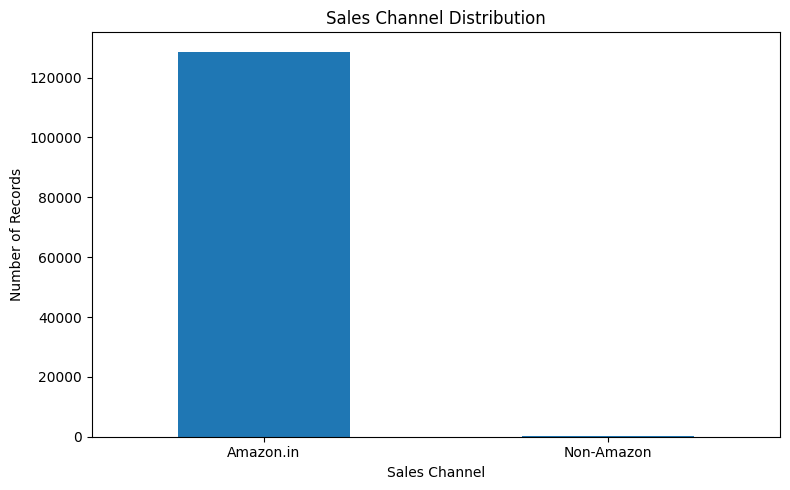

In [79]:
plt.figure(figsize=(8, 5))

sales_channel_counts.plot(kind="bar")

plt.title("Sales Channel Distribution")
plt.xlabel("Sales Channel")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 3.53 Sales Amount by Sales Channel

The total recorded sales amount is aggregated by sales channel to determine
the contribution of each channel to the recorded sales value.

In [80]:
channel_sales = (
    df_clean.groupby("Sales Channel")["Amount"]
    .sum()
    .sort_values(ascending=False)
)

channel_sales

,Amount
Sales Channel,
Amazon.in,78496786.39
Non-Amazon,0.00


## 3.54 Average Sales Amount by Sales Channel

The average recorded sales amount is calculated for each sales channel.

This helps compare the typical recorded transaction value across the available
sales channels.

In [81]:
channel_average_sales = (
    df_clean.groupby("Sales Channel")["Amount"]
    .mean()
    .sort_values(ascending=False)
)

channel_average_sales

,Amount
Sales Channel,
Amazon.in,648.631921
Non-Amazon,NaN


## 3.55 Quantity by Sales Channel

The total quantity recorded for each sales channel is calculated to compare
the volume of units associated with different channels.

In [82]:
channel_quantity = (
    df_clean.groupby("Sales Channel")["Qty"]
    .sum()
    .sort_values(ascending=False)
)

channel_quantity

,Qty
Sales Channel,
Amazon.in,116329
Non-Amazon,167


## 3.56 Sales Channel Performance Summary

Order records, total recorded sales, average recorded sales, and total quantity
are combined into a single sales channel performance table.

This allows the available sales channels to be compared using multiple measures.

In [83]:
channel_performance = pd.DataFrame({
    "Order Records": sales_channel_counts,
    "Total Recorded Sales": channel_sales,
    "Average Recorded Sales": channel_average_sales,
    "Total Quantity": channel_quantity
})

channel_performance

,Order Records,Total Recorded Sales,Average Recorded Sales,Total Quantity
Sales Channel,,,,
Amazon.in,128684,78496786.39,648.631921,116329
Non-Amazon,124,0.00,NaN,167


## 3.57 Sales Amount by Sales Channel Visualization

A bar chart is used to compare the total recorded sales amount across
the available sales channels.

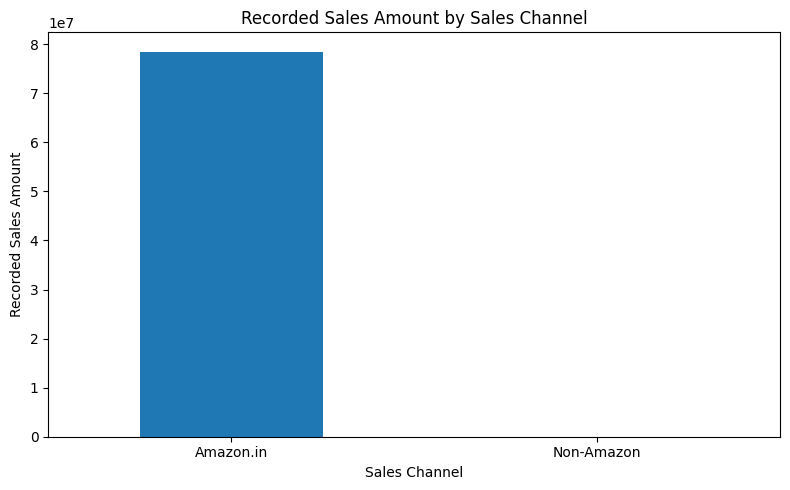

In [84]:
plt.figure(figsize=(8, 5))

channel_sales.plot(kind="bar")

plt.title("Recorded Sales Amount by Sales Channel")
plt.xlabel("Sales Channel")
plt.ylabel("Recorded Sales Amount")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 3.58 Quantity by Sales Channel Visualization

A bar chart is created to compare the total quantity associated with
each sales channel.

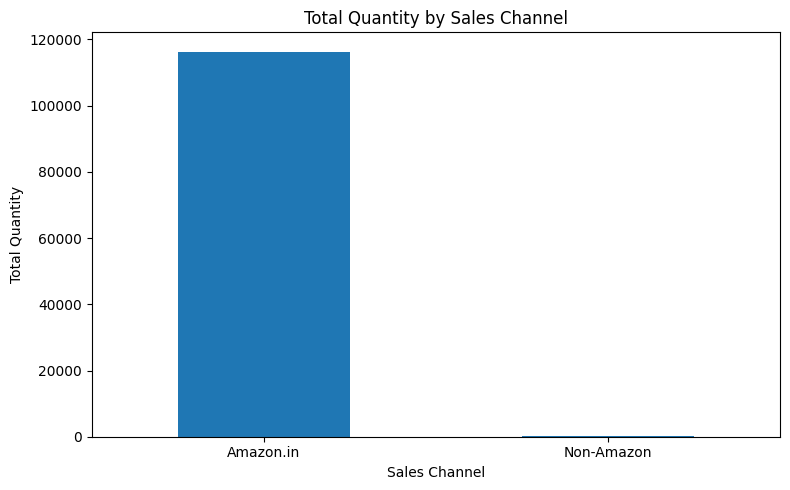

In [85]:
plt.figure(figsize=(8, 5))

channel_quantity.plot(kind="bar")

plt.title("Total Quantity by Sales Channel")
plt.xlabel("Sales Channel")
plt.ylabel("Total Quantity")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 3.59 Highest Recorded Sales Channel

The sales channel with the highest total recorded sales amount is identified
to determine which channel contributes the greatest recorded sales value.

In [86]:
highest_sales_channel = channel_sales.idxmax()
highest_channel_sales = channel_sales.max()

print("Highest recorded sales channel:", highest_sales_channel)
print(
    "Recorded sales amount:",
    round(highest_channel_sales, 2)
)

Highest recorded sales channel: Amazon.in
Recorded sales amount: 78496786.39


## 3.60 Highest-Volume Sales Channel

The sales channel with the highest number of records is identified to determine
which channel has the greatest recorded order volume.

In [87]:
highest_volume_channel = sales_channel_counts.idxmax()
highest_channel_volume = sales_channel_counts.max()

print("Highest-volume sales channel:", highest_volume_channel)
print("Number of records:", highest_channel_volume)

Highest-volume sales channel: Amazon.in
Number of records: 128684


## 3.61 Size Distribution

The distribution of records across different product sizes is analyzed to
understand which sizes occur most frequently in the dataset.

In [88]:
size_counts = df_clean["Size"].value_counts()

size_counts

,count
Size,
M,22350
L,21777
XL,20520
XXL,17783
S,16754
3XL,14626
XS,11033
Free,2250
6XL,738


## 3.62 Size Percentage Distribution

The percentage contribution of each product size is calculated to compare
the relative share of different sizes in the dataset.

In [89]:
size_percentage = (
    df_clean["Size"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

size_percentage

,proportion
Size,
M,17.35
L,16.91
XL,15.93
XXL,13.81
S,13.01
3XL,11.35
XS,8.57
Free,1.75
6XL,0.57


## 3.63 Size Summary

The size counts and percentages are combined into a summary table to provide
a concise overview of the size distribution.

In [90]:
size_summary = pd.DataFrame({
    "Size": size_counts.index,
    "Order Records": size_counts.values,
    "Percentage": size_percentage.values
})

size_summary

,Size,Order Records,Percentage
0,M,22350,17.35
1,L,21777,16.91
2,XL,20520,15.93
3,XXL,17783,13.81
4,S,16754,13.01
5,3XL,14626,11.35
6,XS,11033,8.57
7,Free,2250,1.75
8,6XL,738,0.57
9,5XL,550,0.43


## 3.64 Size Distribution Visualization

A bar chart is created to visually compare the number of records associated
with each product size.

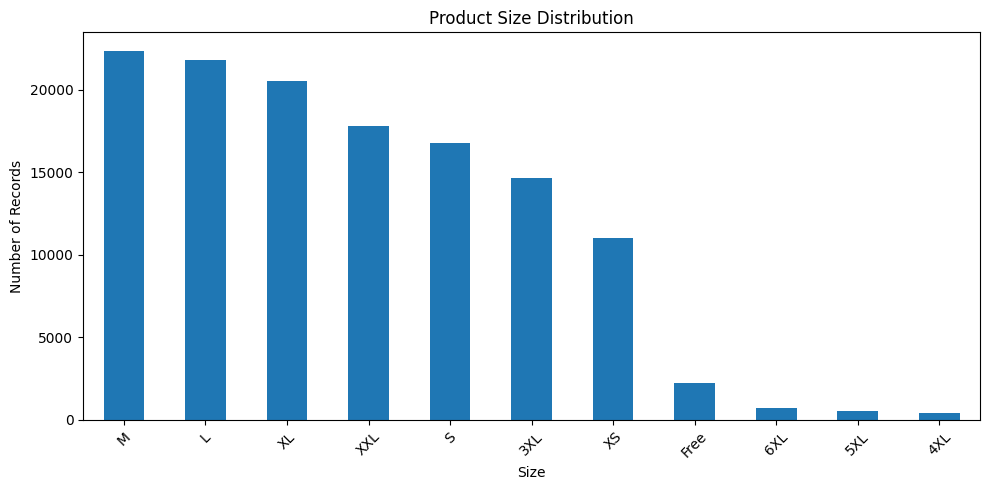

In [91]:
plt.figure(figsize=(10, 5))

size_counts.plot(kind="bar")

plt.title("Product Size Distribution")
plt.xlabel("Size")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 3.65 Recorded Sales Amount by Size

The total recorded sales amount is aggregated by product size to identify
the sizes associated with the greatest recorded sales value.

In [92]:
size_sales = (
    df_clean.groupby("Size")["Amount"]
    .sum()
    .sort_values(ascending=False)
)

size_sales

,Amount
Size,
M,13678295.13
L,13023938.84
XL,12240095.38
XXL,10452621.64
S,10414943.18
3XL,9026104.92
XS,6952253.10
Free,1372676.60
6XL,576249.33


## 3.66 Average Recorded Sales Amount by Size

The average recorded sales amount is calculated for each product size.

This helps compare the typical recorded transaction value across different sizes.

In [93]:
size_average_sales = (
    df_clean.groupby("Size")["Amount"]
    .mean()
    .sort_values(ascending=False)
)

size_average_sales

,Amount
Size,
4XL,819.734412
6XL,817.374936
5XL,808.282567
XS,682.932525
S,666.343134
M,652.964251
3XL,650.764594
Free,644.449108
L,636.525040


## 3.67 Size Performance Summary

Order volume, total recorded sales, and average recorded sales are combined
into a single size-level summary table.

This allows different product sizes to be compared using multiple measures.

In [94]:
size_performance = pd.DataFrame({
    "Order Records": size_counts,
    "Total Recorded Sales": size_sales,
    "Average Recorded Sales": size_average_sales
})

size_performance

,Order Records,Total Recorded Sales,Average Recorded Sales
Size,,,
3XL,14626,9026104.92,650.764594
4XL,427,334451.64,819.734412
5XL,550,425156.63,808.282567
6XL,738,576249.33,817.374936
Free,2250,1372676.60,644.449108
L,21777,13023938.84,636.525040
M,22350,13678295.13,652.964251
S,16754,10414943.18,666.343134
XL,20520,12240095.38,631.127946


## 3.68 Recorded Sales Amount by Size Visualization

A bar chart is used to compare the total recorded sales amount associated
with each product size.

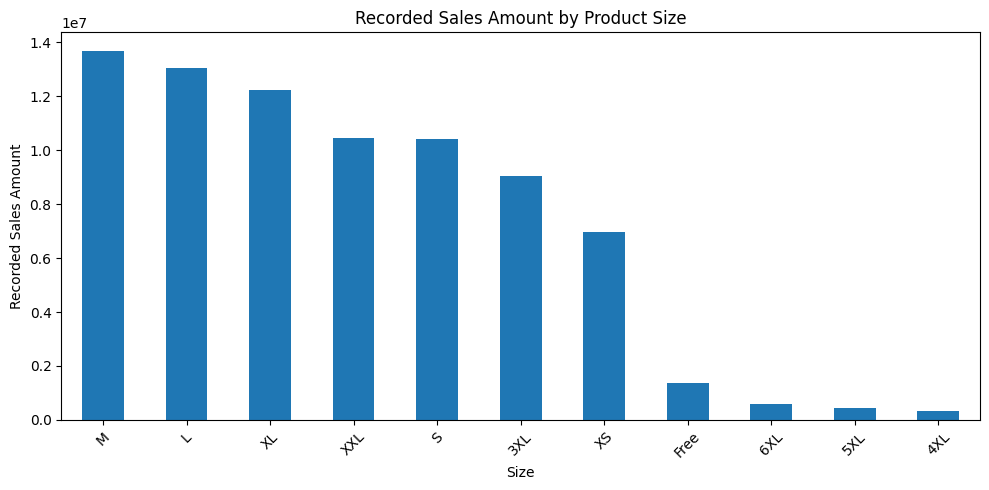

In [95]:
plt.figure(figsize=(10, 5))

size_sales.plot(kind="bar")

plt.title("Recorded Sales Amount by Product Size")
plt.xlabel("Size")
plt.ylabel("Recorded Sales Amount")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 3.69 Highest-Volume Product Size

The product size with the highest number of records is identified to determine
which size has the greatest recorded order volume.

In [96]:
highest_volume_size = size_counts.idxmax()
highest_size_volume = size_counts.max()

print("Highest-volume size:", highest_volume_size)
print("Number of records:", highest_size_volume)

Highest-volume size: M
Number of records: 22350


## 3.70 Highest-Sales Product Size

The product size with the highest total recorded sales amount is identified
to determine which size contributes the greatest recorded sales value.

In [97]:
highest_sales_size = size_sales.idxmax()
highest_size_sales = size_sales.max()

print("Highest-sales size:", highest_sales_size)
print("Recorded sales amount:", round(highest_size_sales, 2))

Highest-sales size: M
Recorded sales amount: 13678295.13


## 3.71 Courier Status Distribution

The distribution of courier statuses is analyzed to understand the current
shipping-related status of orders in the dataset.

In [98]:
courier_status_counts = df_clean["Courier Status"].value_counts()

courier_status_counts

,count
Courier Status,
Shipped,109341
On the Way,6863
Unshipped,6675
Cancelled,5929


## 3.72 Courier Status Percentage Distribution

The percentage contribution of each courier status is calculated to compare
the relative proportion of orders associated with different courier statuses.

In [99]:
courier_status_percentage = (
    df_clean["Courier Status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

courier_status_percentage

,proportion
Courier Status,
Shipped,84.89
On the Way,5.33
Unshipped,5.18
Cancelled,4.60


## 3.73 Courier Status Summary

The courier status counts and percentages are combined into a summary table
to provide a concise overview of the courier status distribution.

In [100]:
courier_status_summary = pd.DataFrame({
    "Courier Status": courier_status_counts.index,
    "Order Records": courier_status_counts.values,
    "Percentage": courier_status_percentage.values
})

courier_status_summary

,Courier Status,Order Records,Percentage
0,Shipped,109341,84.89
1,On the Way,6863,5.33
2,Unshipped,6675,5.18
3,Cancelled,5929,4.60


## 3.74 Courier Status Distribution Visualization

A bar chart is created to visually compare the number of records associated
with each courier status.

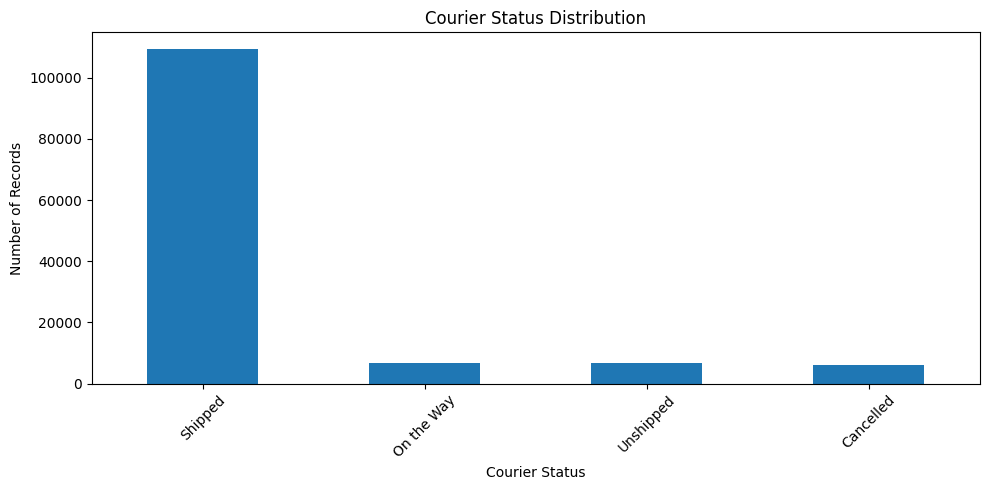

In [101]:
plt.figure(figsize=(10, 5))

courier_status_counts.plot(kind="bar")

plt.title("Courier Status Distribution")
plt.xlabel("Courier Status")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 3.75 Recorded Sales Amount by Courier Status

The total recorded sales amount is aggregated by courier status to compare
the recorded sales value associated with different courier statuses.

In [102]:
courier_sales = (
    df_clean.groupby("Courier Status")["Amount"]
    .sum()
    .sort_values(ascending=False)
)

courier_sales

,Amount
Courier Status,
Shipped,70971225.00
Unshipped,4339691.00
On the Way,3185870.39
Cancelled,0.00


## 3.76 Quantity by Courier Status

The total quantity is aggregated by courier status to compare the volume of
units associated with different courier statuses.

In [103]:
courier_quantity = (
    df_clean.groupby("Courier Status")["Qty"]
    .sum()
    .sort_values(ascending=False)
)

courier_quantity

,Qty
Courier Status,
Shipped,109749
Unshipped,6747
On the Way,0
Cancelled,0


## 3.77 Courier Status Performance Summary

Order records, total recorded sales, and total quantity are combined into
a single summary table to compare the different courier statuses.

In [104]:
courier_performance = pd.DataFrame({
    "Order Records": courier_status_counts,
    "Total Recorded Sales": courier_sales,
    "Total Quantity": courier_quantity
})

courier_performance

,Order Records,Total Recorded Sales,Total Quantity
Courier Status,,,
Cancelled,5929,0.00,0
On the Way,6863,3185870.39,0
Shipped,109341,70971225.00,109749
Unshipped,6675,4339691.00,6747


## 3.78 Recorded Sales Amount by Courier Status Visualization

A bar chart is used to compare the total recorded sales amount associated
with each courier status.

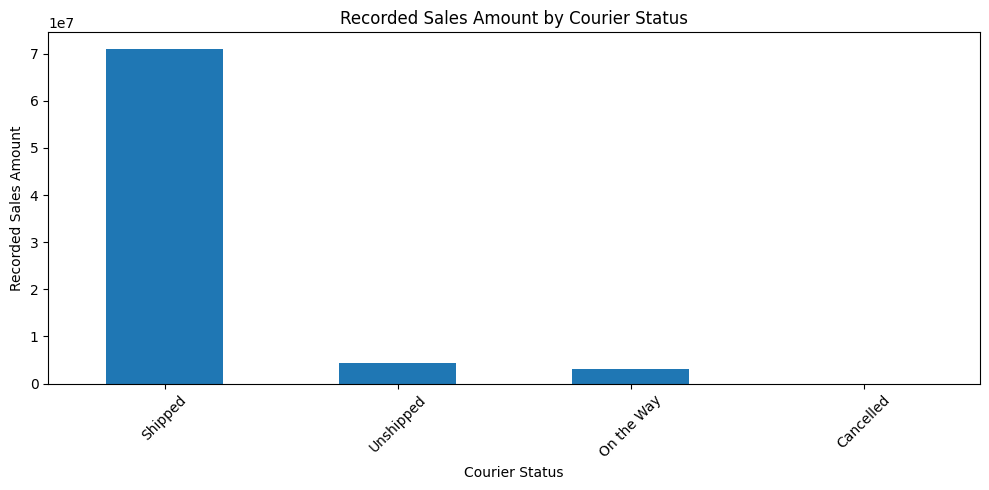

In [105]:
plt.figure(figsize=(10, 5))

courier_sales.plot(kind="bar")

plt.title("Recorded Sales Amount by Courier Status")
plt.xlabel("Courier Status")
plt.ylabel("Recorded Sales Amount")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 3.79 Most Common Courier Status

The courier status with the highest number of records is identified to
determine the most frequently occurring courier status in the dataset.

In [106]:
most_common_courier_status = courier_status_counts.idxmax()
most_common_courier_count = courier_status_counts.max()

print("Most common courier status:", most_common_courier_status)
print("Number of records:", most_common_courier_count)

Most common courier status: Shipped
Number of records: 109341


## 3.80 Highest-Sales Courier Status

The courier status with the highest total recorded sales amount is identified
to determine which courier status is associated with the greatest recorded
sales value.

In [107]:
highest_courier_sales_status = courier_sales.idxmax()
highest_courier_sales = courier_sales.max()

print("Highest-sales courier status:", highest_courier_sales_status)
print("Recorded sales amount:", round(highest_courier_sales, 2))

Highest-sales courier status: Shipped
Recorded sales amount: 70971225.0


## 3.81 Fulfillment Distribution

The distribution of fulfillment methods is analyzed to understand how
orders are processed through the different fulfillment methods.

In [108]:
fulfilment_counts = df_clean["Fulfilment"].value_counts()

fulfilment_counts

,count
Fulfilment,
Amazon,89595
Merchant,39213


## 3.82 Fulfillment Percentage Distribution

The percentage contribution of each fulfillment method is calculated to
compare the relative share of orders handled through different methods.

In [109]:
fulfilment_percentage = (
    df_clean["Fulfilment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

fulfilment_percentage

,proportion
Fulfilment,
Amazon,69.56
Merchant,30.44


## 3.83 Fulfillment Summary

The number and percentage of records associated with each fulfillment
method are combined into a summary table.

In [110]:
fulfilment_summary = pd.DataFrame({
    "Fulfilment": fulfilment_counts.index,
    "Order Records": fulfilment_counts.values,
    "Percentage": fulfilment_percentage.values
})

fulfilment_summary

,Fulfilment,Order Records,Percentage
0,Amazon,89595,69.56
1,Merchant,39213,30.44


## 3.84 Fulfillment Distribution Visualization

A bar chart is used to visually compare the number of records associated
with each fulfillment method.

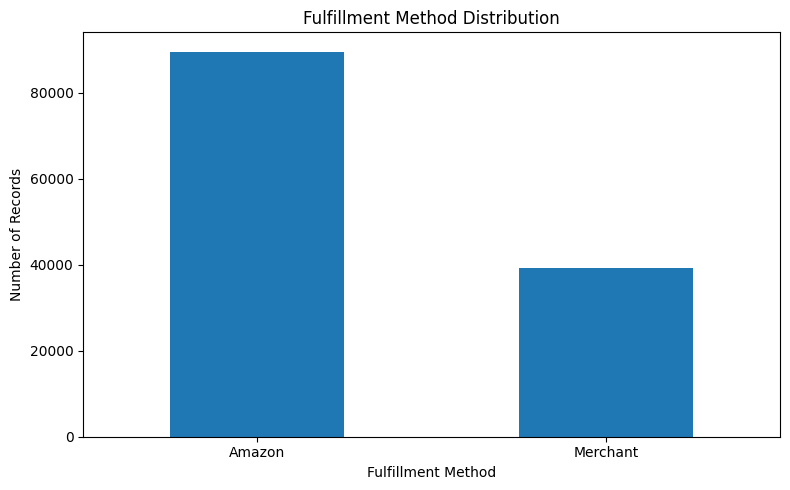

In [111]:
plt.figure(figsize=(8, 5))

fulfilment_counts.plot(kind="bar")

plt.title("Fulfillment Method Distribution")
plt.xlabel("Fulfillment Method")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 3.85 Recorded Sales Amount by Fulfillment

The total recorded sales amount is aggregated by fulfillment method to
compare the sales value associated with different fulfillment methods.

In [112]:
fulfilment_sales = (
    df_clean.groupby("Fulfilment")["Amount"]
    .sum()
    .sort_values(ascending=False)
)

fulfilment_sales

,Amount
Fulfilment,
Amazon,54262165.00
Merchant,24234621.39


## 3.86 Quantity by Fulfillment

The total quantity is aggregated by fulfillment method to compare the
volume of units associated with each fulfillment method.

In [113]:
fulfilment_quantity = (
    df_clean.groupby("Fulfilment")["Qty"]
    .sum()
    .sort_values(ascending=False)
)

fulfilment_quantity

,Qty
Fulfilment,
Amazon,83990
Merchant,32506


## 3.87 Average Recorded Sales Amount by Fulfillment

The average recorded sales amount is calculated for each fulfillment
method to compare the typical recorded sales value associated with
different fulfillment methods.

In [114]:
fulfilment_average_sales = (
    df_clean.groupby("Fulfilment")["Amount"]
    .mean()
    .sort_values(ascending=False)
)

fulfilment_average_sales

,Amount
Fulfilment,
Amazon,649.519583
Merchant,646.653184


## 3.88 Fulfillment Performance Summary

Order records, total recorded sales, total quantity, and average recorded
sales amount are combined to provide an overall comparison of fulfillment
methods.

In [115]:
fulfilment_performance = pd.DataFrame({
    "Order Records": fulfilment_counts,
    "Total Recorded Sales": fulfilment_sales,
    "Total Quantity": fulfilment_quantity,
    "Average Recorded Sales": fulfilment_average_sales
})

fulfilment_performance

,Order Records,Total Recorded Sales,Total Quantity,Average Recorded Sales
Fulfilment,,,,
Amazon,89595,54262165.00,83990,649.519583
Merchant,39213,24234621.39,32506,646.653184


## 3.89 Most Common Fulfillment Method

The fulfillment method with the highest number of records is identified
to determine the most frequently used fulfillment method in the dataset.

In [116]:
most_common_fulfilment = fulfilment_counts.idxmax()
most_common_fulfilment_count = fulfilment_counts.max()

print("Most common fulfillment method:", most_common_fulfilment)
print("Number of records:", most_common_fulfilment_count)

Most common fulfillment method: Amazon
Number of records: 89595


## 3.90 Highest-Sales Fulfillment Method

The fulfillment method with the highest total recorded sales amount is
identified to determine which fulfillment method is associated with the
greatest recorded sales value.

In [117]:
highest_fulfilment_sales = fulfilment_sales.idxmax()
highest_fulfilment_sales_amount = fulfilment_sales.max()

print("Highest-sales fulfillment method:", highest_fulfilment_sales)
print(
    "Recorded sales amount:",
    round(highest_fulfilment_sales_amount, 2)
)

Highest-sales fulfillment method: Amazon
Recorded sales amount: 54262165.0


## 3.91 B2B Order Distribution

The distribution of B2B and non-B2B orders is analyzed to understand
the proportion of business-to-business transactions in the dataset.

In [118]:
b2b_counts = df_clean["B2B"].value_counts()

b2b_counts

,count
B2B,
False,127937
True,871


## 3.92 B2B Percentage Distribution

The percentage contribution of B2B and non-B2B orders is calculated
to compare their relative share of the dataset.

In [119]:
b2b_percentage = (
    df_clean["B2B"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

b2b_percentage

,proportion
B2B,
False,99.32
True,0.68


## 3.93 B2B Summary

The B2B order counts and percentages are combined into a summary table
to provide a concise overview of B2B and non-B2B transactions.

In [120]:
b2b_summary = pd.DataFrame({
    "B2B": b2b_counts.index,
    "Order Records": b2b_counts.values,
    "Percentage": b2b_percentage.values
})

b2b_summary

,B2B,Order Records,Percentage
0,False,127937,99.32
1,True,871,0.68


## 3.94 B2B Distribution Visualization

A bar chart is used to compare the number of B2B and non-B2B records
in the dataset.

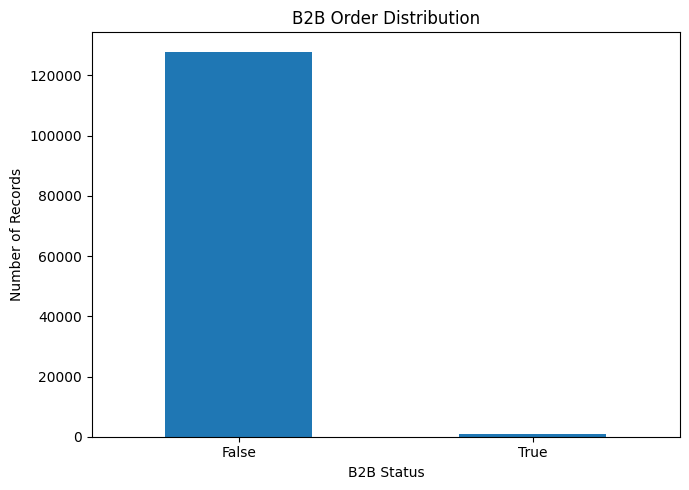

In [121]:
plt.figure(figsize=(7, 5))

b2b_counts.plot(kind="bar")

plt.title("B2B Order Distribution")
plt.xlabel("B2B Status")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 3.95 Recorded Sales Amount by B2B Status

The total recorded sales amount is aggregated by B2B status to compare
the recorded sales value associated with B2B and non-B2B transactions.

In [122]:
b2b_sales = (
    df_clean.groupby("B2B")["Amount"]
    .sum()
    .sort_values(ascending=False)
)

b2b_sales

,Amount
B2B,
False,77905565.60
True,591220.79


## 3.96 Quantity by B2B Status

The total quantity is aggregated by B2B status to compare the volume
of units associated with B2B and non-B2B transactions.

In [123]:
b2b_quantity = (
    df_clean.groupby("B2B")["Qty"]
    .sum()
    .sort_values(ascending=False)
)

b2b_quantity

,Qty
B2B,
False,115656
True,840


## 3.97 Average Recorded Sales by B2B Status

The average recorded sales amount is calculated for each B2B status
to compare the typical recorded transaction value.

In [124]:
b2b_average_sales = (
    df_clean.groupby("B2B")["Amount"]
    .mean()
    .sort_values(ascending=False)
)

b2b_average_sales

,Amount
B2B,
True,701.329526
False,648.262262


## 3.98 B2B Performance Summary

Order records, total recorded sales, total quantity, and average recorded
sales are combined into a single summary table for B2B analysis.

In [125]:
b2b_performance = pd.DataFrame({
    "Order Records": b2b_counts,
    "Total Recorded Sales": b2b_sales,
    "Total Quantity": b2b_quantity,
    "Average Recorded Sales": b2b_average_sales
})

b2b_performance

,Order Records,Total Recorded Sales,Total Quantity,Average Recorded Sales
B2B,,,,
False,127937,77905565.60,115656,648.262262
True,871,591220.79,840,701.329526


## 3.99 B2B Sales Comparison

The total recorded sales associated with B2B and non-B2B transactions
are compared visually to understand their relative contribution to
recorded sales.

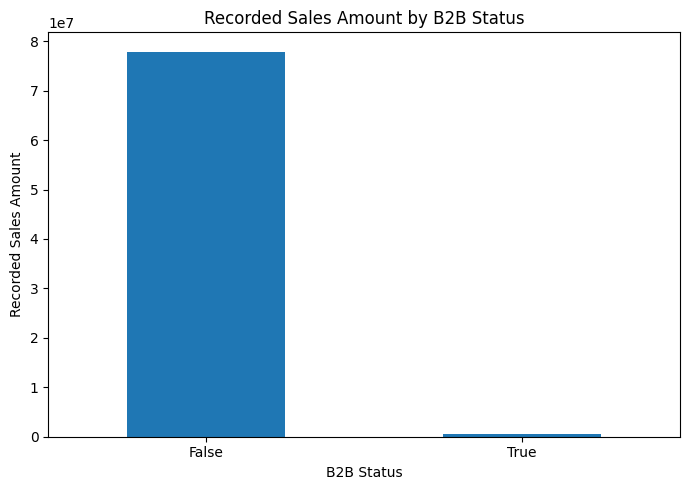

In [126]:
plt.figure(figsize=(7, 5))

b2b_sales.plot(kind="bar")

plt.title("Recorded Sales Amount by B2B Status")
plt.xlabel("B2B Status")
plt.ylabel("Recorded Sales Amount")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 3.100 Highest-Sales B2B Segment

The B2B status with the highest total recorded sales amount is identified
to determine which segment contributes the greatest recorded sales value.

In [127]:
highest_b2b_sales_status = b2b_sales.idxmax()
highest_b2b_sales = b2b_sales.max()

print("Highest-sales B2B status:", highest_b2b_sales_status)
print("Recorded sales amount:", round(highest_b2b_sales, 2))

Highest-sales B2B status: False
Recorded sales amount: 77905565.6


## 3.101 Identifying Geographical Variables

The dataset columns are reviewed to identify the variables that can be used
for geographical analysis.

The identified geographical variables will be used to study the distribution
of sales across different regions.

In [128]:
geo_columns = [
    col for col in df_clean.columns
    if any(word in col.lower() for word in [
        "city", "state", "region", "postal", "zip", "country"
    ])
]

geo_columns

['ship-city', 'ship-state', 'ship-postal-code', 'ship-country']

## 3.102 State-wise Order Distribution

The number of order records is analyzed across different states to
understand the geographical distribution of orders.

In [129]:
state_order_counts = (
    df_clean["ship-state"]
    .value_counts()
)

state_order_counts.head(20)

,count
ship-state,
MAHARASHTRA,22234
KARNATAKA,17296
TAMIL NADU,11470
TELANGANA,11319
UTTAR PRADESH,10633
DELHI,6770
KERALA,6574
WEST BENGAL,5955
ANDHRA PRADESH,5421


## 3.103 State-wise Sales Distribution

The total recorded sales amount is aggregated by state to identify
the states contributing the highest recorded sales value.

In [130]:
state_sales = (
    df_clean.groupby("ship-state")["Amount"]
    .sum()
    .sort_values(ascending=False)
)

state_sales.head(20)

,Amount
ship-state,
MAHARASHTRA,13318966.38
KARNATAKA,10465387.03
TELANGANA,6909670.08
UTTAR PRADESH,6814126.08
TAMIL NADU,6510503.73
DELHI,4228503.97
KERALA,3821997.58
WEST BENGAL,3503223.44
ANDHRA PRADESH,3214859.86


## 3.104 State-wise Quantity Distribution

The total quantity of products is aggregated by state to compare
the volume of products associated with different states.

In [131]:
state_quantity = (
    df_clean.groupby("ship-state")["Qty"]
    .sum()
    .sort_values(ascending=False)
)

state_quantity.head(20)

,Qty
ship-state,
MAHARASHTRA,20304
KARNATAKA,15876
TAMIL NADU,10400
TELANGANA,10243
UTTAR PRADESH,9495
DELHI,6144
KERALA,5802
WEST BENGAL,5311
ANDHRA PRADESH,4810


## 3.105 Top States by Order Records

The states with the highest number of order records are identified
to determine the major geographical markets based on order volume.

In [132]:
top_states_orders = state_order_counts.head(10)

top_states_orders

,count
ship-state,
MAHARASHTRA,22234
KARNATAKA,17296
TAMIL NADU,11470
TELANGANA,11319
UTTAR PRADESH,10633
DELHI,6770
KERALA,6574
WEST BENGAL,5955
ANDHRA PRADESH,5421


## 3.106 Visualization of Top States by Orders

A bar chart is used to visually compare the order volume across the
top states.

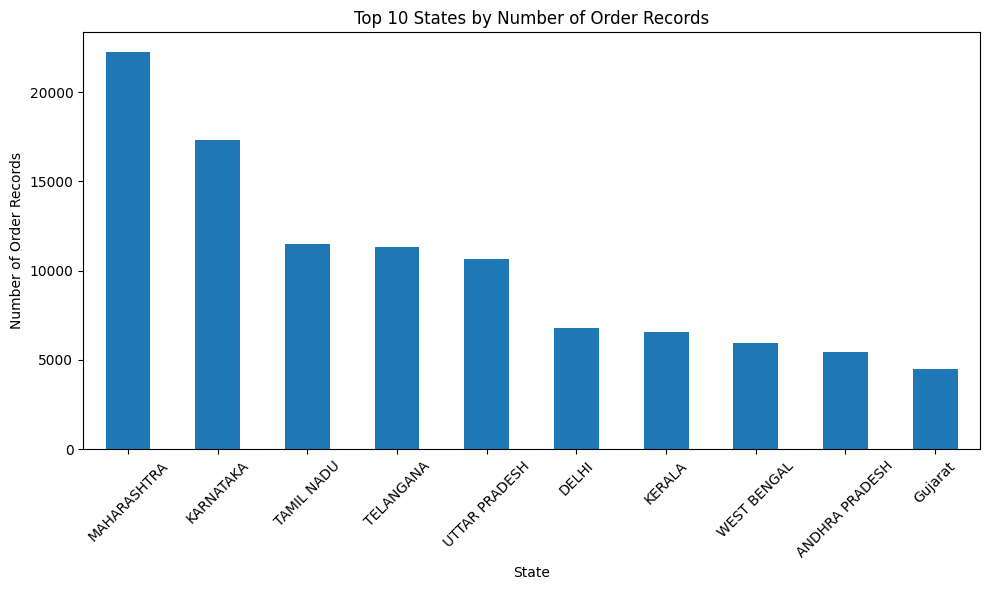

In [133]:
plt.figure(figsize=(10, 6))

top_states_orders.plot(kind="bar")

plt.title("Top 10 States by Number of Order Records")
plt.xlabel("State")
plt.ylabel("Number of Order Records")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 3.107 Top States by Recorded Sales

The states with the highest total recorded sales amount are identified
to determine the major geographical markets based on recorded sales value.

In [134]:
top_states_sales = state_sales.head(10)

top_states_sales

,Amount
ship-state,
MAHARASHTRA,13318966.38
KARNATAKA,10465387.03
TELANGANA,6909670.08
UTTAR PRADESH,6814126.08
TAMIL NADU,6510503.73
DELHI,4228503.97
KERALA,3821997.58
WEST BENGAL,3503223.44
ANDHRA PRADESH,3214859.86


## 3.108 Visualization of Top States by Sales

A bar chart is used to visually compare the total recorded sales amount
across the top states.

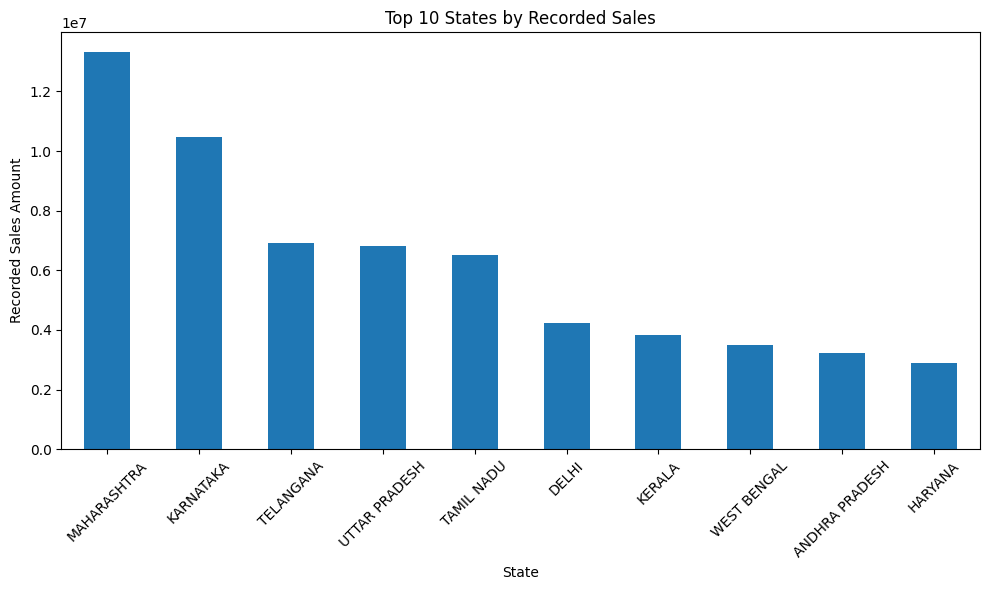

In [135]:
plt.figure(figsize=(10, 6))

top_states_sales.plot(kind="bar")

plt.title("Top 10 States by Recorded Sales")
plt.xlabel("State")
plt.ylabel("Recorded Sales Amount")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 3.109 City-wise Order Distribution

The number of order records is analyzed across cities to identify
the cities with the highest order volume.

In [136]:
city_order_counts = (
    df_clean["ship-city"]
    .value_counts()
)

city_order_counts.head(20)

,count
ship-city,
BENGALURU,11191
HYDERABAD,8067
MUMBAI,6115
NEW DELHI,5784
CHENNAI,5421
PUNE,3856
KOLKATA,2378
GURUGRAM,1865
THANE,1700


## 3.110 Top Cities by Order Records

The cities with the highest number of order records are identified
to determine the major markets based on order volume.

In [137]:
top_cities_orders = city_order_counts.head(10)

top_cities_orders

,count
ship-city,
BENGALURU,11191
HYDERABAD,8067
MUMBAI,6115
NEW DELHI,5784
CHENNAI,5421
PUNE,3856
KOLKATA,2378
GURUGRAM,1865
THANE,1700


## 3.111 Visualization of Top Cities by Orders

A bar chart is used to visually compare the order volume across
the top cities.

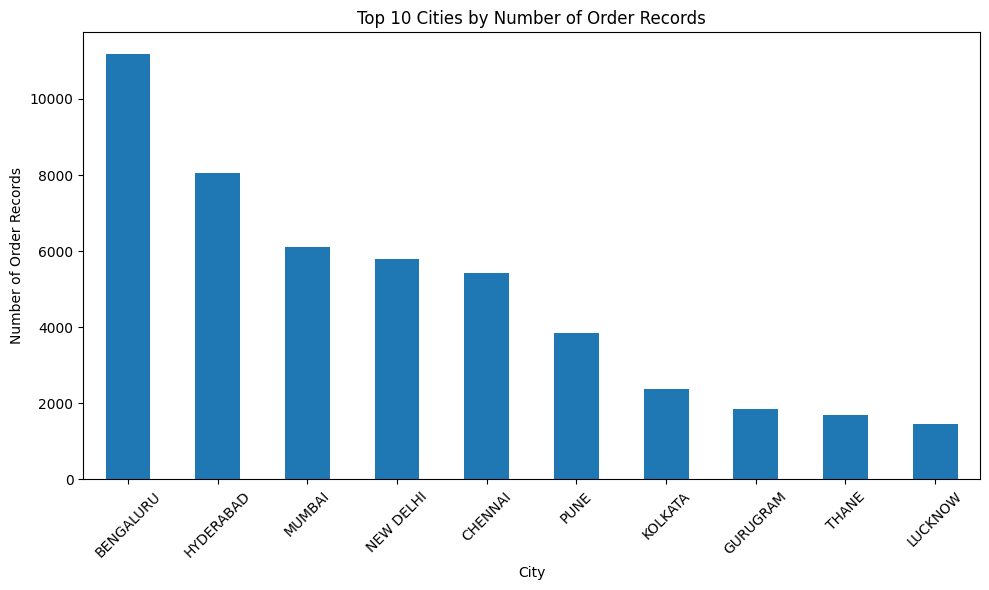

In [138]:
plt.figure(figsize=(10, 6))

top_cities_orders.plot(kind="bar")

plt.title("Top 10 Cities by Number of Order Records")
plt.xlabel("City")
plt.ylabel("Number of Order Records")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 3.112 Country-wise Order Distribution

The number of order records is analyzed by country to understand
the geographical distribution of the dataset at the country level.

In [139]:
country_order_counts = (
    df_clean["ship-country"]
    .value_counts()
)

country_order_counts

,count
ship-country,
IN,128775


## 3.113 Country-wise Recorded Sales

The total recorded sales amount is aggregated by country to compare
the recorded sales contribution across countries.

In [140]:
country_sales = (
    df_clean.groupby("ship-country")["Amount"]
    .sum()
    .sort_values(ascending=False)
)

country_sales

,Amount
ship-country,
IN,78478115.39


## 3.114 Country-wise Sales Visualization

A bar chart is used to compare the recorded sales amount across
the countries represented in the dataset.

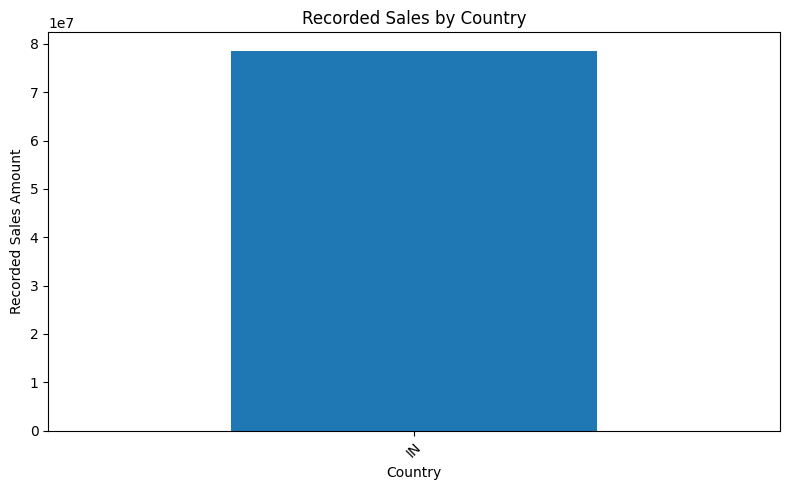

In [141]:
plt.figure(figsize=(8, 5))

country_sales.plot(kind="bar")

plt.title("Recorded Sales by Country")
plt.xlabel("Country")
plt.ylabel("Recorded Sales Amount")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 3.115 Top Cities by Recorded Sales

The cities with the highest total recorded sales amount are identified
to determine the major city-level markets based on recorded sales value.

In [142]:
city_sales = (
    df_clean.groupby("ship-city")["Amount"]
    .sum()
    .sort_values(ascending=False)
)

city_sales.head(10)

,Amount
ship-city,
BENGALURU,6836614.65
HYDERABAD,4941790.25
MUMBAI,3696704.04
NEW DELHI,3608277.78
CHENNAI,3098745.74
PUNE,2337978.18
KOLKATA,1412815.87
GURUGRAM,1220562.74
THANE,1003878.29


## 3.116 Visualization of Top Cities by Sales

A bar chart is used to visually compare the recorded sales amount
across the top cities.

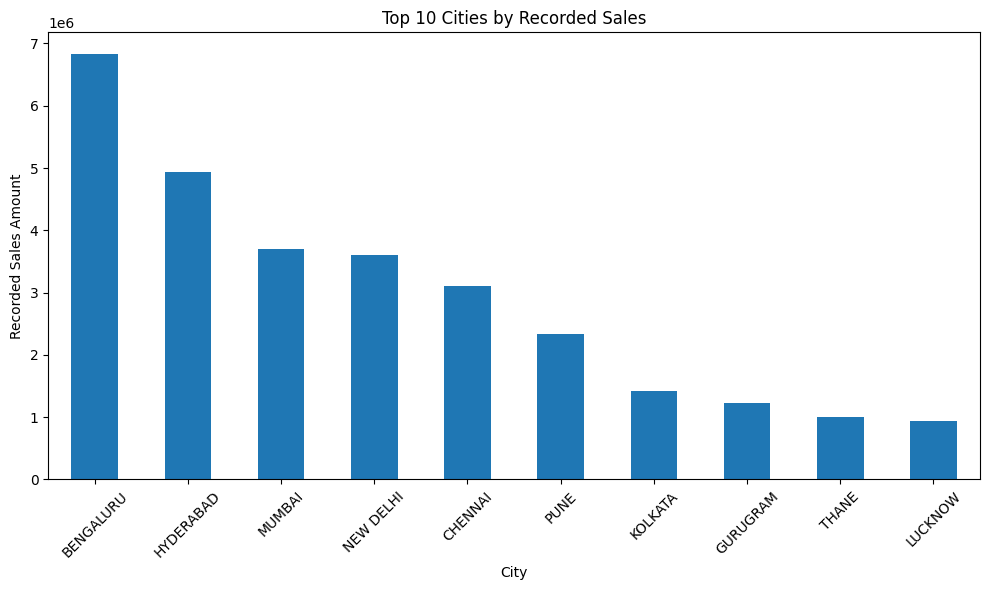

In [143]:
top_cities_sales = city_sales.head(10)

plt.figure(figsize=(10, 6))

top_cities_sales.plot(kind="bar")

plt.title("Top 10 Cities by Recorded Sales")
plt.xlabel("City")
plt.ylabel("Recorded Sales Amount")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 3.117 Top States by Quantity

The states with the highest total quantity of products are identified
to determine the major geographical markets based on product volume.

In [144]:
top_states_quantity = state_quantity.head(10)

top_states_quantity

,Qty
ship-state,
MAHARASHTRA,20304
KARNATAKA,15876
TAMIL NADU,10400
TELANGANA,10243
UTTAR PRADESH,9495
DELHI,6144
KERALA,5802
WEST BENGAL,5311
ANDHRA PRADESH,4810


## 3.118 Visualization of Top States by Quantity

A bar chart is used to compare the total quantity of products
associated with the top states.

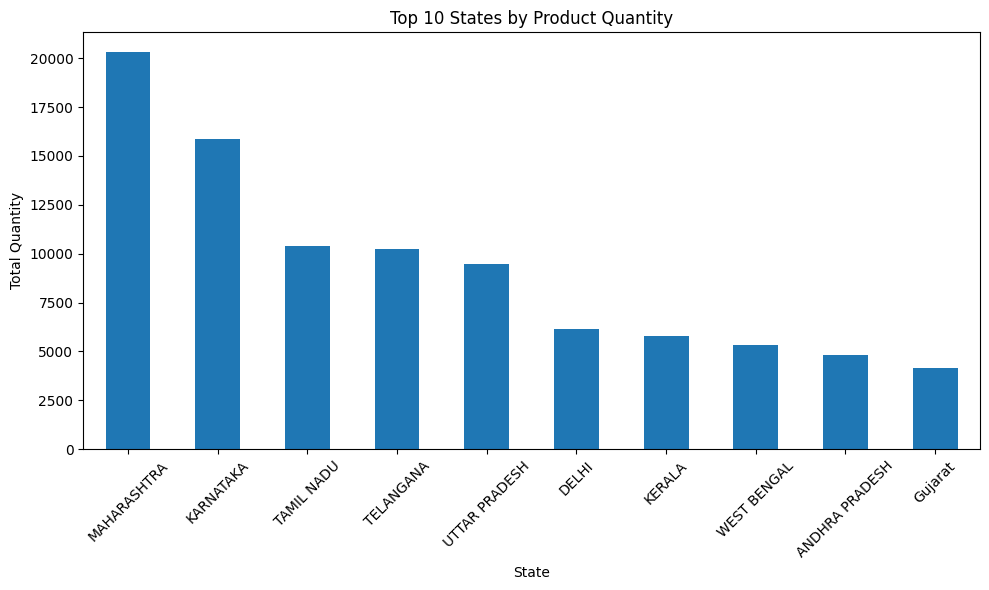

In [145]:
plt.figure(figsize=(10, 6))

top_states_quantity.plot(kind="bar")

plt.title("Top 10 States by Product Quantity")
plt.xlabel("State")
plt.ylabel("Total Quantity")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 3.119 Postal Code Order Distribution

Postal codes are analyzed to identify locations with a high
concentration of order records at a more detailed geographical level.

In [146]:
postal_order_counts = (
    df_clean["ship-postal-code"]
    .value_counts()
)

postal_order_counts.head(10)

,count
ship-postal-code,
201301.0,1006
122001.0,686
560037.0,632
560068.0,613
560076.0,580
560043.0,499
401107.0,493
500072.0,490
560100.0,488


## 3.120 Geographical Performance Summary

The leading states and cities based on order records and recorded sales
are summarized to provide an overall view of the major geographical markets.

In [147]:
print("Top state by order records:", state_order_counts.idxmax())
print("Order records:", state_order_counts.max())

print("\nTop state by recorded sales:", state_sales.idxmax())
print("Recorded sales:", round(state_sales.max(), 2))

print("\nTop city by order records:", city_order_counts.idxmax())
print("Order records:", city_order_counts.max())

print("\nTop city by recorded sales:", city_sales.idxmax())
print("Recorded sales:", round(city_sales.max(), 2))

print("\nTop country by order records:", country_order_counts.idxmax())
print("Order records:", country_order_counts.max())

Top state by order records: MAHARASHTRA
Order records: 22234

Top state by recorded sales: MAHARASHTRA
Recorded sales: 13318966.38

Top city by order records: BENGALURU
Order records: 11191

Top city by recorded sales: BENGALURU
Recorded sales: 6836614.65

Top country by order records: IN
Order records: 128775


## 3.121 Leading Geographical Market

The state with the highest recorded sales amount is identified as the
leading geographical market based on recorded sales value.

In [148]:
leading_state = state_sales.idxmax()
leading_state_sales = state_sales.max()

print("Leading geographical market:", leading_state)
print("Recorded sales amount:", round(leading_state_sales, 2))

Leading geographical market: MAHARASHTRA
Recorded sales amount: 13318966.38


## 3.122 Geographical Analysis Conclusion

The geographical analysis examined order distribution and recorded sales
across states, cities, countries, and postal codes. The results help
identify major geographical markets and areas with higher order and
sales activity. These findings can support decisions related to market
focus, regional sales planning, and distribution strategy.

## 3.123 Product Category Distribution

The distribution of order records across product categories is analyzed
to identify the most frequently ordered product categories.

In [149]:
category_counts = (
    df_clean["Category"]
    .value_counts()
)

category_counts

,count
Category,
T-shirt,50219
Shirt,49804
Blazzer,15489
Trousers,10607
Perfume,1157
Wallet,926
Socks,439
Shoes,164
Watch,3


## 3.124 Product Category Percentage Distribution

The percentage contribution of each product category is calculated
to compare the relative share of different categories in the dataset.

In [150]:
category_percentage = (
    df_clean["Category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

category_percentage

,proportion
Category,
T-shirt,38.99
Shirt,38.67
Blazzer,12.02
Trousers,8.23
Perfume,0.90
Wallet,0.72
Socks,0.34
Shoes,0.13
Watch,0.00


## 3.125 Product Category Summary

The number and percentage of order records are combined to provide
a concise summary of product category distribution.

In [151]:
category_summary = pd.DataFrame({
    "Category": category_counts.index,
    "Order Records": category_counts.values,
    "Percentage": category_percentage.values
})

category_summary

,Category,Order Records,Percentage
0,T-shirt,50219,38.99
1,Shirt,49804,38.67
2,Blazzer,15489,12.02
3,Trousers,10607,8.23
4,Perfume,1157,0.90
5,Wallet,926,0.72
6,Socks,439,0.34
7,Shoes,164,0.13
8,Watch,3,0.00


## 3.126 Product Category Visualization

A bar chart is used to visually compare the number of order records
across product categories.

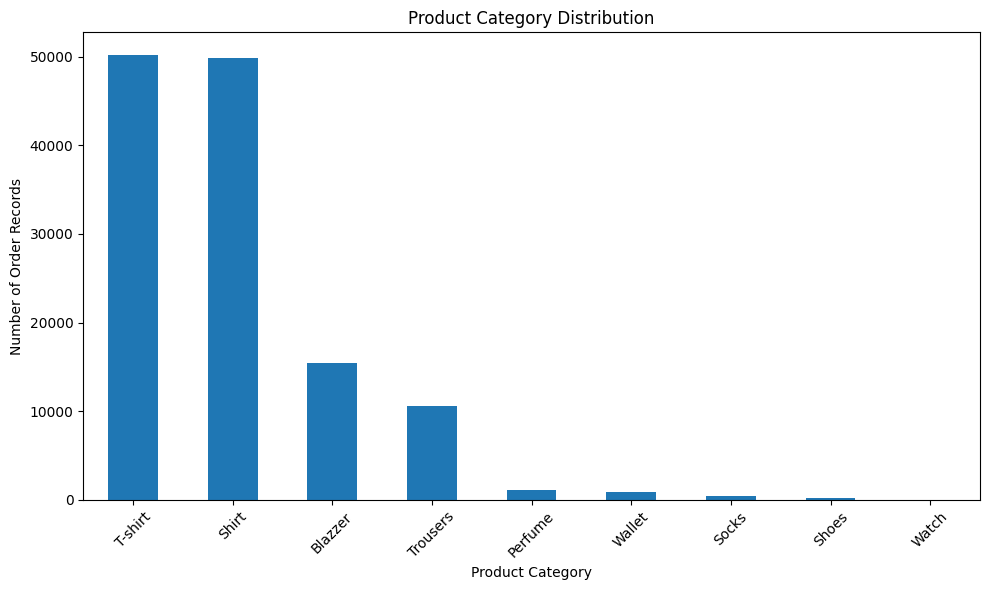

In [152]:
plt.figure(figsize=(10, 6))

category_counts.plot(kind="bar")

plt.title("Product Category Distribution")
plt.xlabel("Product Category")
plt.ylabel("Number of Order Records")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 3.127 Product Size Distribution

The distribution of order records across different product sizes is
analyzed to identify the sizes that occur most frequently in the dataset.

In [153]:
size_counts = (
    df_clean["Size"]
    .value_counts()
)

size_counts

,count
Size,
M,22350
L,21777
XL,20520
XXL,17783
S,16754
3XL,14626
XS,11033
Free,2250
6XL,738


## 3.128 Product Size Percentage Distribution

The percentage contribution of each product size is calculated to
compare the relative share of different sizes in the dataset.

In [154]:
size_percentage = (
    df_clean["Size"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

size_percentage

,proportion
Size,
M,17.35
L,16.91
XL,15.93
XXL,13.81
S,13.01
3XL,11.35
XS,8.57
Free,1.75
6XL,0.57


## 3.129 Product Size Summary

The number and percentage of order records are combined to provide
a concise summary of the product size distribution.

In [155]:
size_summary = pd.DataFrame({
    "Size": size_counts.index,
    "Order Records": size_counts.values,
    "Percentage": size_percentage.values
})

size_summary

,Size,Order Records,Percentage
0,M,22350,17.35
1,L,21777,16.91
2,XL,20520,15.93
3,XXL,17783,13.81
4,S,16754,13.01
5,3XL,14626,11.35
6,XS,11033,8.57
7,Free,2250,1.75
8,6XL,738,0.57
9,5XL,550,0.43


## 3.130 Product Size Visualization

A bar chart is used to visually compare the number of order records
across different product sizes.

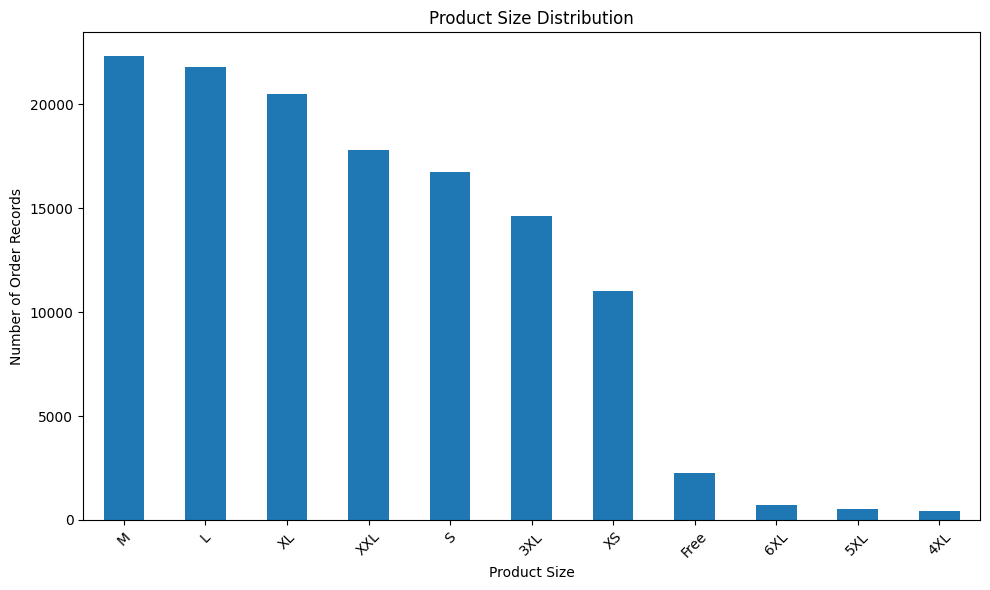

In [156]:
plt.figure(figsize=(10, 6))

size_counts.plot(kind="bar")

plt.title("Product Size Distribution")
plt.xlabel("Product Size")
plt.ylabel("Number of Order Records")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 3.131 Quantity by Product Category

The total quantity of products is aggregated by product category
to identify categories associated with higher product volume.

In [157]:
category_quantity = (
    df_clean.groupby("Category")["Qty"]
    .sum()
    .sort_values(ascending=False)
)

category_quantity

,Qty
Category,
T-shirt,45228
Shirt,44978
Blazzer,13934
Trousers,9889
Perfume,1051
Wallet,863
Socks,398
Shoes,152
Watch,3


## 3.132 Recorded Sales by Product Category

The total recorded sales amount is aggregated by product category
to identify categories contributing the highest recorded sales value.

In [158]:
category_sales = (
    df_clean.groupby("Category")["Amount"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

,Amount
Category,
T-shirt,39154132.17
Shirt,21269768.70
Blazzer,11208506.12
Trousers,5341305.30
Perfume,789419.66
Wallet,458408.18
Socks,150397.50
Shoes,123933.76
Watch,915.00


## 3.133 Category Sales Visualization

A bar chart is used to compare the recorded sales amount across
different product categories.

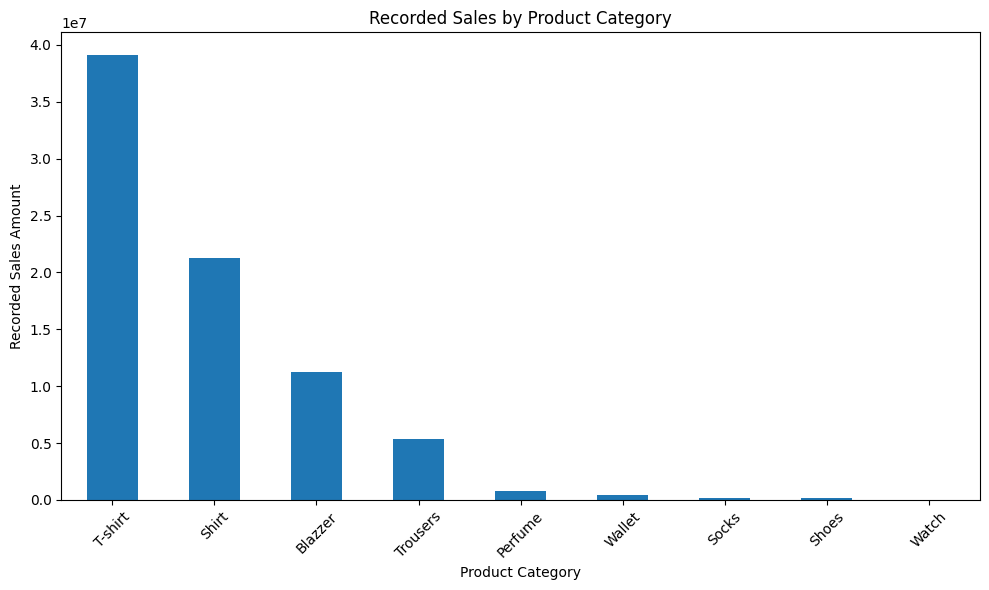

In [159]:
plt.figure(figsize=(10, 6))

category_sales.plot(kind="bar")

plt.title("Recorded Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Recorded Sales Amount")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 3.134 Quantity by Product Size

The total quantity of products is aggregated by size to identify
the sizes associated with higher product volume.

In [160]:
size_quantity = (
    df_clean.groupby("Size")["Qty"]
    .sum()
    .sort_values(ascending=False)
)

size_quantity

,Qty
Size,
M,20116
L,19680
XL,18609
XXL,16226
S,15022
3XL,13346
XS,9829
Free,2069
6XL,688


## 3.135 Recorded Sales by Product Size

The total recorded sales amount is aggregated by product size to identify
the sizes contributing the highest recorded sales value.

In [161]:
size_sales = (
    df_clean.groupby("Size")["Amount"]
    .sum()
    .sort_values(ascending=False)
)

size_sales

,Amount
Size,
M,13678295.13
L,13023938.84
XL,12240095.38
XXL,10452621.64
S,10414943.18
3XL,9026104.92
XS,6952253.10
Free,1372676.60
6XL,576249.33


## 3.136 Average Recorded Sales by Product Category

The average recorded sales amount is calculated for each product category
to compare the typical recorded transaction value across categories.

In [162]:
category_average_sales = (
    df_clean.groupby("Category")["Amount"]
    .mean()
    .sort_values(ascending=False)
)

category_average_sales

,Amount
Category,
T-shirt,833.421289
Shoes,799.572645
Blazzer,762.794754
Perfume,723.574390
Trousers,526.185134
Wallet,520.327106
Shirt,455.992469
Socks,358.943914
Watch,305.000000


## 3.137 Average Recorded Sales by Product Size

The average recorded sales amount is calculated for each product size
to compare the typical recorded transaction value across sizes.

In [163]:
size_average_sales = (
    df_clean.groupby("Size")["Amount"]
    .mean()
    .sort_values(ascending=False)
)

size_average_sales

,Amount
Size,
4XL,819.734412
6XL,817.374936
5XL,808.282567
XS,682.932525
S,666.343134
M,652.964251
3XL,650.764594
Free,644.449108
L,636.525040


## 3.138 Product Category Performance Summary

Order records, total quantity, total recorded sales, and average recorded
sales are combined to provide an overall comparison of product categories.

In [164]:
category_performance = pd.DataFrame({
    "Order Records": category_counts,
    "Total Quantity": category_quantity,
    "Total Recorded Sales": category_sales,
    "Average Recorded Sales": category_average_sales
})

category_performance

,Order Records,Total Quantity,Total Recorded Sales,Average Recorded Sales
Category,,,,
Blazzer,15489,13934,11208506.12,762.794754
Perfume,1157,1051,789419.66,723.574390
Shirt,49804,44978,21269768.70,455.992469
Shoes,164,152,123933.76,799.572645
Socks,439,398,150397.50,358.943914
T-shirt,50219,45228,39154132.17,833.421289
Trousers,10607,9889,5341305.30,526.185134
Wallet,926,863,458408.18,520.327106
Watch,3,3,915.00,305.000000


## 3.139 Product Size Performance Summary

Order records, total quantity, total recorded sales, and average recorded
sales are combined to provide an overall comparison of product sizes.

In [165]:
size_performance = pd.DataFrame({
    "Order Records": size_counts,
    "Total Quantity": size_quantity,
    "Total Recorded Sales": size_sales,
    "Average Recorded Sales": size_average_sales
})

size_performance

,Order Records,Total Quantity,Total Recorded Sales,Average Recorded Sales
Size,,,,
3XL,14626,13346,9026104.92,650.764594
4XL,427,398,334451.64,819.734412
5XL,550,513,425156.63,808.282567
6XL,738,688,576249.33,817.374936
Free,2250,2069,1372676.60,644.449108
L,21777,19680,13023938.84,636.525040
M,22350,20116,13678295.13,652.964251
S,16754,15022,10414943.18,666.343134
XL,20520,18609,12240095.38,631.127946


## 3.140 Highest-Volume Product Category

The product category with the highest total quantity is identified
to determine the category associated with the greatest product volume.

In [166]:
highest_volume_category = category_quantity.idxmax()
highest_category_quantity = category_quantity.max()

print("Highest-volume category:", highest_volume_category)
print("Total quantity:", highest_category_quantity)

Highest-volume category: T-shirt
Total quantity: 45228


## 3.141 Highest-Sales Product Category

The product category with the highest total recorded sales amount is
identified to determine the category contributing the greatest recorded
sales value.

In [167]:
highest_sales_category = category_sales.idxmax()
highest_category_sales = category_sales.max()

print("Highest-sales category:", highest_sales_category)
print(
    "Recorded sales amount:",
    round(highest_category_sales, 2)
)

Highest-sales category: T-shirt
Recorded sales amount: 39154132.17


## 3.142 Highest-Volume Product Size

The product size with the highest total quantity is identified
to determine the size associated with the greatest product volume.

In [168]:
highest_volume_size = size_quantity.idxmax()
highest_size_quantity = size_quantity.max()

print("Highest-volume size:", highest_volume_size)
print("Total quantity:", highest_size_quantity)

Highest-volume size: M
Total quantity: 20116


## 3.143 Highest-Sales Product Size

The product size with the highest total recorded sales amount is
identified to determine the size contributing the greatest recorded
sales value.

In [169]:
highest_sales_size = size_sales.idxmax()
highest_size_sales = size_sales.max()

print("Highest-sales size:", highest_sales_size)
print(
    "Recorded sales amount:",
    round(highest_size_sales, 2)
)

Highest-sales size: M
Recorded sales amount: 13678295.13


## 3.144 Product Category Quantity Visualization

A bar chart is used to compare the total quantity of products associated
with each product category.

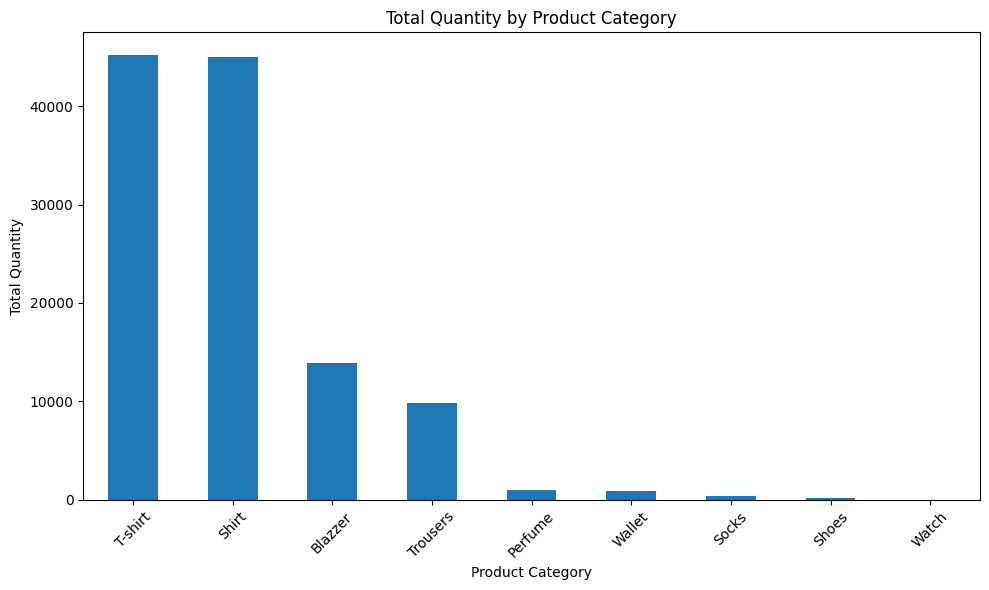

In [170]:
plt.figure(figsize=(10, 6))

category_quantity.plot(kind="bar")

plt.title("Total Quantity by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Quantity")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 3.145 Product Size Quantity Visualization

A bar chart is used to compare the total quantity of products associated
with each product size.

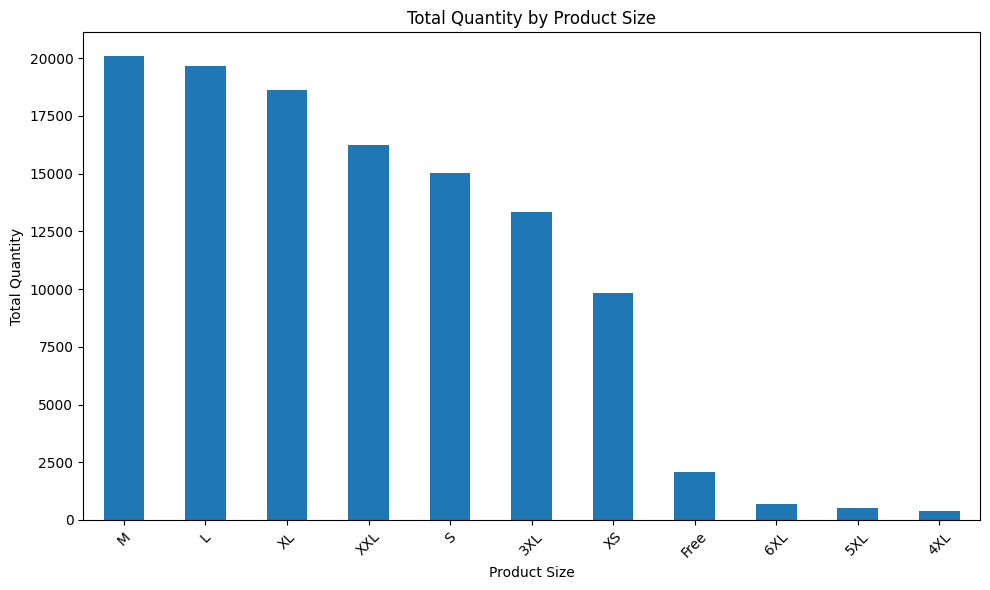

In [171]:
plt.figure(figsize=(10, 6))

size_quantity.plot(kind="bar")

plt.title("Total Quantity by Product Size")
plt.xlabel("Product Size")
plt.ylabel("Total Quantity")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 3.146 Product Size Sales Visualization

A bar chart is used to compare the total recorded sales amount associated
with different product sizes.

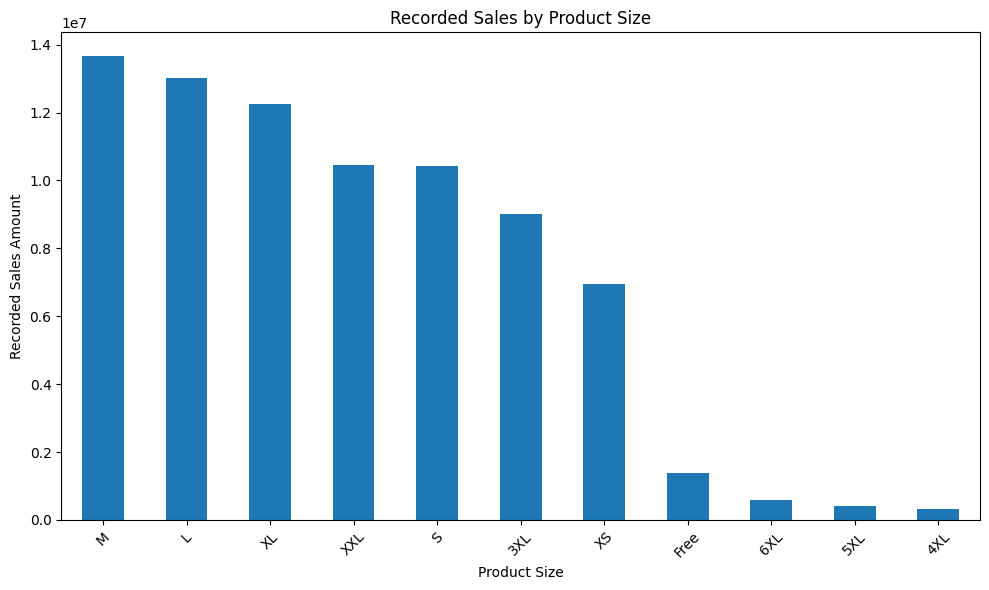

In [172]:
plt.figure(figsize=(10, 6))

size_sales.plot(kind="bar")

plt.title("Recorded Sales by Product Size")
plt.xlabel("Product Size")
plt.ylabel("Recorded Sales Amount")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 3.147 Product Category and Size Insights

The product analysis compares categories and sizes using order records,
quantity, total recorded sales, and average recorded sales.

The results help identify products and sizes with higher order volume,
product quantity, and recorded sales contribution. These findings can
support inventory planning and product-focused business decisions.

## 3.148 Product Analysis Conclusion

The product analysis examined product categories and sizes using order
volume, quantity, total recorded sales, and average recorded sales.

The analysis identifies the strongest-performing categories and sizes
within the available transaction data. These findings can help support
inventory planning, product prioritization, and sales strategy.

## 3.149 Identifying Customer-Related Variables

The dataset columns are reviewed to identify variables that can be used
to study customer and order behavior.

The available identifiers and transaction variables will be used to
construct meaningful customer-level or order-level analysis.

In [173]:
customer_columns = [
    col for col in df_clean.columns
    if any(word in col.lower() for word in [
        "order", "customer", "buyer", "email", "phone"
    ])
]

customer_columns

['Order ID']

## 3.150 Number of Unique Orders

The number of unique Order IDs is calculated to determine the number
of distinct orders represented in the dataset.

In [174]:
unique_orders = df_clean["Order ID"].nunique()

print("Number of unique orders:", unique_orders)

Number of unique orders: 120229


## 3.151 Order Records per Order ID

The number of records associated with each Order ID is calculated
to understand whether individual orders contain multiple product records.

In [175]:
order_record_counts = (
    df_clean["Order ID"]
    .value_counts()
)

order_record_counts.head(10)

,count
Order ID,
171-5057375-2831560,12
403-4984515-8861958,12
403-0173977-3041148,11
404-9932919-6662730,11
408-3317403-1729937,10
171-4310662-2005103,9
406-9002076-4152331,9
404-3701762-8241125,9
408-2964501-8373155,9


## 3.152 Distribution of Records per Order

The distribution of records associated with each order is examined
to understand the structure and product-line composition of orders.

In [176]:
order_record_counts.describe()

,count
count,120229.000000
mean,1.071355
std,0.335722
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,12.000000


## 3.153 Total Quantity per Order

The total quantity of products is aggregated for each Order ID
to measure the product volume associated with individual orders.

In [177]:
order_quantity = (
    df_clean.groupby("Order ID")["Qty"]
    .sum()
    .sort_values(ascending=False)
)

order_quantity.head(10)

,Qty
Order ID,
S02-5278980-4327051,15
405-4755854-9568304,13
S02-6828927-1180856,13
408-3363121-6123562,12
403-4984515-8861958,12
403-0173977-3041148,11
404-9932919-6662730,11
408-3317403-1729937,10
408-2964501-8373155,9


## 3.154 Recorded Sales per Order

The total recorded sales amount is aggregated for each Order ID
to measure the recorded value associated with individual orders.

In [178]:
order_sales = (
    df_clean.groupby("Order ID")["Amount"]
    .sum()
    .sort_values(ascending=False)
)

order_sales.head(10)

,Amount
Order ID,
408-3363121-6123562,8636.0
405-8750647-4224357,8081.0
403-4288285-8521928,6993.0
404-9932919-6662730,6832.0
408-3317403-1729937,6680.0
408-4410167-4971567,6536.0
405-4755854-9568304,6535.0
406-9002076-4152331,6509.0
171-0706521-2133101,6313.0


## 3.155 Average Order Value

The average recorded sales amount per unique order is calculated
to understand the typical order value in the dataset.

In [179]:
average_order_value = order_sales.mean()

print(
    "Average recorded sales per order:",
    round(average_order_value, 2)
)

Average recorded sales per order: 652.89


## 3.156 Order Value Segmentation

Orders are divided into value-based segments using their recorded sales
amount. This provides a simple behavioral segmentation of orders into
lower-value, medium-value, and higher-value groups.

In [180]:
order_segments = pd.qcut(
    order_sales,
    q=3,
    labels=["Low Value", "Medium Value", "High Value"]
)

order_segments.value_counts().sort_index()

,count
Amount,
Low Value,40301
Medium Value,39865
High Value,40063


## 3.157 Order Segment Summary

The number of orders and their percentage contribution are calculated
for each order-value segment.

In [181]:
order_segment_summary = pd.DataFrame({
    "Order Count": order_segments.value_counts().sort_index(),
    "Percentage": (
        order_segments.value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )
})

order_segment_summary

,Order Count,Percentage
Amount,,
Low Value,40301,33.52
Medium Value,39865,33.16
High Value,40063,33.32


## 3.158 Average Order Value by Segment

The average recorded sales amount is calculated for each order-value
segment to compare the typical value of low-, medium-, and high-value
orders.

In [182]:
segment_average_value = (
    pd.DataFrame({
        "Order Value": order_sales,
        "Segment": order_segments
    })
    .groupby("Segment", observed=True)["Order Value"]
    .mean()
)

segment_average_value

,Order Value
Segment,
Low Value,300.135173
Medium Value,611.093221
High Value,1049.342474


## 3.159 Quantity by Order-Value Segment

The average product quantity per order is calculated for each
order-value segment to compare purchasing volume across the segments.

In [183]:
order_quantity_by_segment = (
    pd.DataFrame({
        "Quantity": order_quantity,
        "Segment": order_segments
    })
    .groupby("Segment", observed=True)["Quantity"]
    .mean()
)

order_quantity_by_segment

,Quantity
Segment,
Low Value,0.785489
Medium Value,0.964982
High Value,1.157452


## 3.160 Order Value Segment Visualization

A bar chart is used to visualize the distribution of orders across
the low-value, medium-value, and high-value segments.

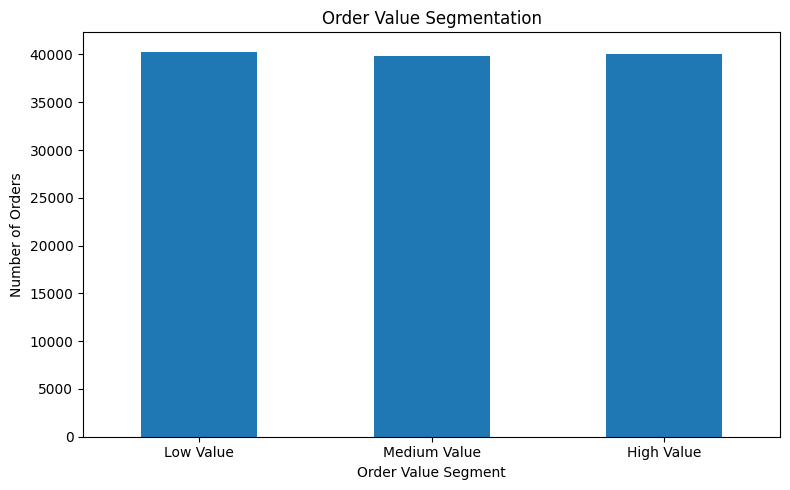

In [184]:
plt.figure(figsize=(8, 5))

order_segments.value_counts().sort_index().plot(kind="bar")

plt.title("Order Value Segmentation")
plt.xlabel("Order Value Segment")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 3.161 Orders by State

The number of order records is aggregated by shipping state to identify
the states contributing the highest number of orders.

In [185]:
state_order_counts = (
    df_clean["ship-state"]
    .dropna()
    .value_counts()
)

state_order_counts.head(15)

,count
ship-state,
MAHARASHTRA,22234
KARNATAKA,17296
TAMIL NADU,11470
TELANGANA,11319
UTTAR PRADESH,10633
DELHI,6770
KERALA,6574
WEST BENGAL,5955
ANDHRA PRADESH,5421


## 3.162 Percentage of Orders by State

The percentage contribution of each shipping state to the total number
of available state-level order records is calculated.

In [186]:
state_order_percentage = (
    df_clean["ship-state"]
    .dropna()
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

state_order_percentage.head(15)

,proportion
ship-state,
MAHARASHTRA,17.27
KARNATAKA,13.43
TAMIL NADU,8.91
TELANGANA,8.79
UTTAR PRADESH,8.26
DELHI,5.26
KERALA,5.11
WEST BENGAL,4.62
ANDHRA PRADESH,4.21


## 3.163 Recorded Sales by State

The total recorded sales amount is aggregated by shipping state to
identify the states contributing the highest recorded sales value.

In [187]:
state_sales = (
    df_clean.dropna(subset=["ship-state"])
    .groupby("ship-state")["Amount"]
    .sum()
    .sort_values(ascending=False)
)

state_sales.head(15)

,Amount
ship-state,
MAHARASHTRA,13318966.38
KARNATAKA,10465387.03
TELANGANA,6909670.08
UTTAR PRADESH,6814126.08
TAMIL NADU,6510503.73
DELHI,4228503.97
KERALA,3821997.58
WEST BENGAL,3503223.44
ANDHRA PRADESH,3214859.86


## 3.164 Product Quantity by State

The total quantity of products is aggregated by shipping state to
identify regions associated with higher product volume.

In [188]:
state_quantity = (
    df_clean.dropna(subset=["ship-state"])
    .groupby("ship-state")["Qty"]
    .sum()
    .sort_values(ascending=False)
)

state_quantity.head(15)

,Qty
ship-state,
MAHARASHTRA,20304
KARNATAKA,15876
TAMIL NADU,10400
TELANGANA,10243
UTTAR PRADESH,9495
DELHI,6144
KERALA,5802
WEST BENGAL,5311
ANDHRA PRADESH,4810


## 3.165 Top States by Order Volume

The states with the highest number of order records are identified
to highlight the major geographical markets represented in the data.

In [189]:
top_states = state_order_counts.head(10)

top_states

,count
ship-state,
MAHARASHTRA,22234
KARNATAKA,17296
TAMIL NADU,11470
TELANGANA,11319
UTTAR PRADESH,10633
DELHI,6770
KERALA,6574
WEST BENGAL,5955
ANDHRA PRADESH,5421


## 3.166 State-Level Order Visualization

A bar chart is used to visualize the top states according to their
number of order records.

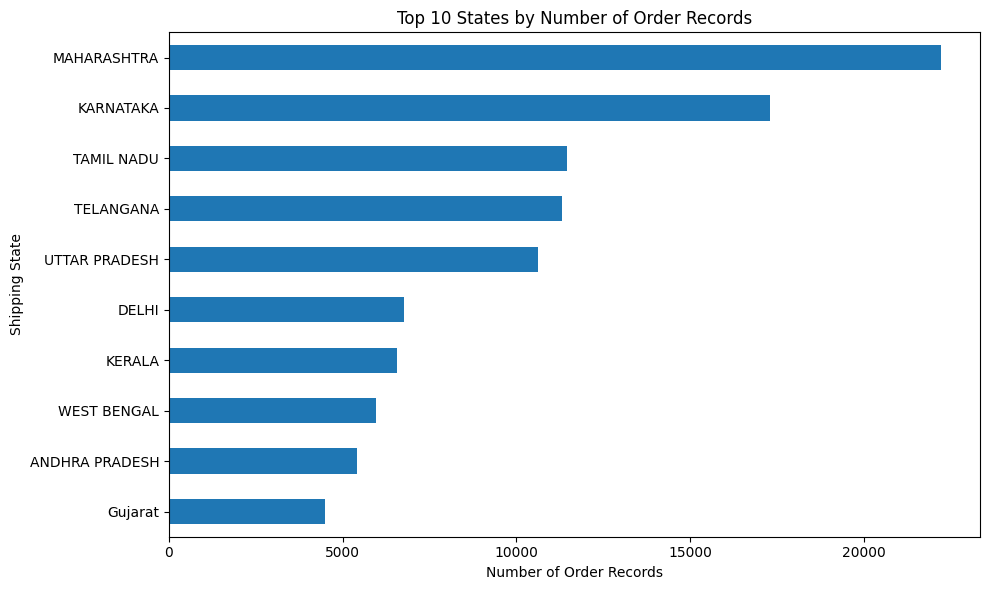

In [190]:
plt.figure(figsize=(10, 6))

top_states.sort_values().plot(kind="barh")

plt.title("Top 10 States by Number of Order Records")
plt.xlabel("Number of Order Records")
plt.ylabel("Shipping State")

plt.tight_layout()
plt.show()

## 3.167 Orders by City

The number of order records is aggregated by shipping city to identify
the cities contributing the highest number of orders.

In [191]:
city_order_counts = (
    df_clean["ship-city"]
    .dropna()
    .value_counts()
)

city_order_counts.head(15)

,count
ship-city,
BENGALURU,11191
HYDERABAD,8067
MUMBAI,6115
NEW DELHI,5784
CHENNAI,5421
PUNE,3856
KOLKATA,2378
GURUGRAM,1865
THANE,1700


## 3.168 Recorded Sales by City

The total recorded sales amount is aggregated by shipping city to
identify cities contributing the highest recorded sales value.

In [192]:
city_sales = (
    df_clean.dropna(subset=["ship-city"])
    .groupby("ship-city")["Amount"]
    .sum()
    .sort_values(ascending=False)
)

city_sales.head(15)

,Amount
ship-city,
BENGALURU,6836614.65
HYDERABAD,4941790.25
MUMBAI,3696704.04
NEW DELHI,3608277.78
CHENNAI,3098745.74
PUNE,2337978.18
KOLKATA,1412815.87
GURUGRAM,1220562.74
THANE,1003878.29


## 3.169 Product Quantity by City

The total quantity of products is aggregated by shipping city to
identify cities associated with higher product volume.

In [193]:
city_quantity = (
    df_clean.dropna(subset=["ship-city"])
    .groupby("ship-city")["Qty"]
    .sum()
    .sort_values(ascending=False)
)

city_quantity.head(15)

,Qty
ship-city,
BENGALURU,10401
HYDERABAD,7327
MUMBAI,5640
NEW DELHI,5241
CHENNAI,4937
PUNE,3532
KOLKATA,2163
GURUGRAM,1731
THANE,1538


## 3.170 Top Cities by Order Volume

The cities with the highest number of order records are identified
to highlight the major city-level markets represented in the dataset.

In [194]:
top_cities = city_order_counts.head(10)

top_cities

,count
ship-city,
BENGALURU,11191
HYDERABAD,8067
MUMBAI,6115
NEW DELHI,5784
CHENNAI,5421
PUNE,3856
KOLKATA,2378
GURUGRAM,1865
THANE,1700


## 3.171 City-Level Order Visualization

A bar chart is used to visualize the top cities according to their
number of order records.

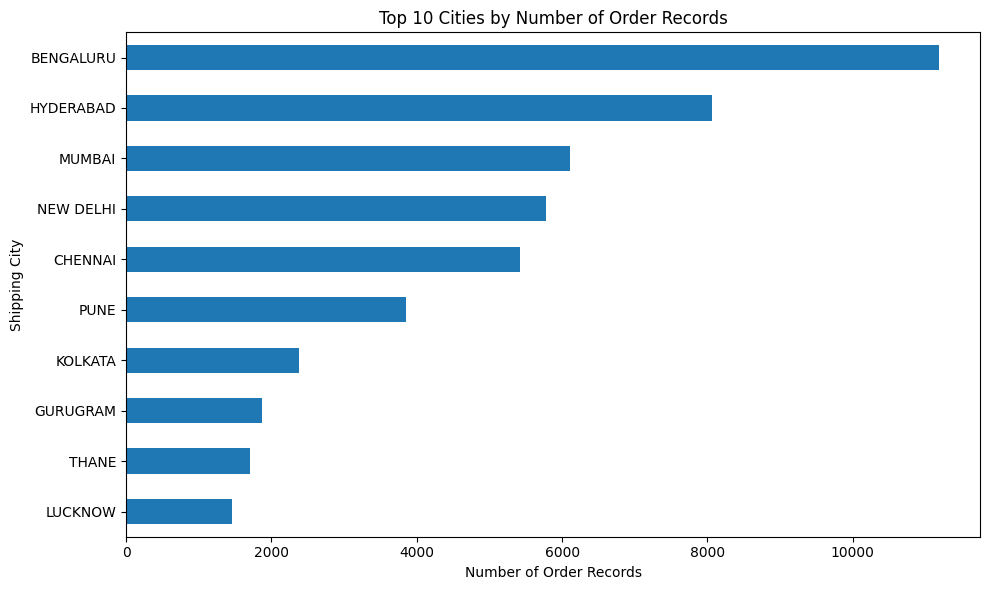

In [195]:
plt.figure(figsize=(10, 6))

top_cities.sort_values().plot(kind="barh")

plt.title("Top 10 Cities by Number of Order Records")
plt.xlabel("Number of Order Records")
plt.ylabel("Shipping City")

plt.tight_layout()
plt.show()

## 3.172 Location and Order-Value Segmentation

The order-value segments are combined with shipping-state information
to examine how low-, medium-, and high-value orders are distributed
across different geographical markets.

In [196]:
location_segments = df_clean[
    ["Order ID", "ship-state"]
].dropna().drop_duplicates()

location_segments = location_segments.merge(
    order_segments.rename("Order Segment"),
    left_on="Order ID",
    right_index=True,
    how="inner"
)

location_segments.head(10)

,Order ID,ship-state,Order Segment
0,405-8078784-5731545,MAHARASHTRA,Medium Value
1,171-9198151-1101146,KARNATAKA,Low Value
2,404-0687676-7273146,MAHARASHTRA,Low Value
3,403-9615377-8133951,PUDUCHERRY,High Value
4,407-1069790-7240320,TAMIL NADU,Medium Value
5,404-1490984-4578765,UTTAR PRADESH,High Value
6,408-5748499-6859555,CHANDIGARH,Medium Value
7,406-7807733-3785945,TELANGANA,Low Value
8,407-5443024-5233168,TELANGANA,Low Value
9,402-4393761-0311520,TAMIL NADU,Low Value


## 3.173 Order Segments by State

The number of low-, medium-, and high-value orders is summarized for
each shipping state to compare order-value behavior across geographical
markets.

In [197]:
state_segment_counts = pd.crosstab(
    location_segments["ship-state"],
    location_segments["Order Segment"]
)

state_segment_counts.head(15)

Order Segment,Low Value,Medium Value,High Value
ship-state,,,
ANDAMAN & NICOBAR,80,83,78
ANDHRA PRADESH,1925,1396,1649
APO,1,0,0
AR,0,1,0
ARUNACHAL PRADESH,22,60,46
ASSAM,543,521,537
Arunachal Pradesh,0,3,0
Arunachal pradesh,2,0,0
BIHAR,566,633,787


## 3.174 Top States by High-Value Orders

The number of high-value orders is examined across shipping states
to identify geographical markets with a greater concentration of
higher-value orders.

In [198]:
high_value_by_state = (
    state_segment_counts["High Value"]
    .sort_values(ascending=False)
)

high_value_by_state.head(10)

,High Value
ship-state,
MAHARASHTRA,6476
KARNATAKA,5408
UTTAR PRADESH,3758
TELANGANA,3616
TAMIL NADU,3014
DELHI,2268
KERALA,1785
ANDHRA PRADESH,1649
WEST BENGAL,1616


## 3.175 Highest High-Value Order State

The shipping state with the highest number of high-value orders is
identified to highlight the geographical market with the greatest
concentration of high-value orders.

In [199]:
highest_high_value_state = high_value_by_state.idxmax()
highest_high_value_count = high_value_by_state.max()

print("State with most high-value orders:", highest_high_value_state)
print("Number of high-value orders:", highest_high_value_count)

State with most high-value orders: MAHARASHTRA
Number of high-value orders: 6476


## 3.176 State-Level Order Segment Visualization

A stacked bar chart is used to compare the distribution of low-,
medium-, and high-value orders across the major shipping states.

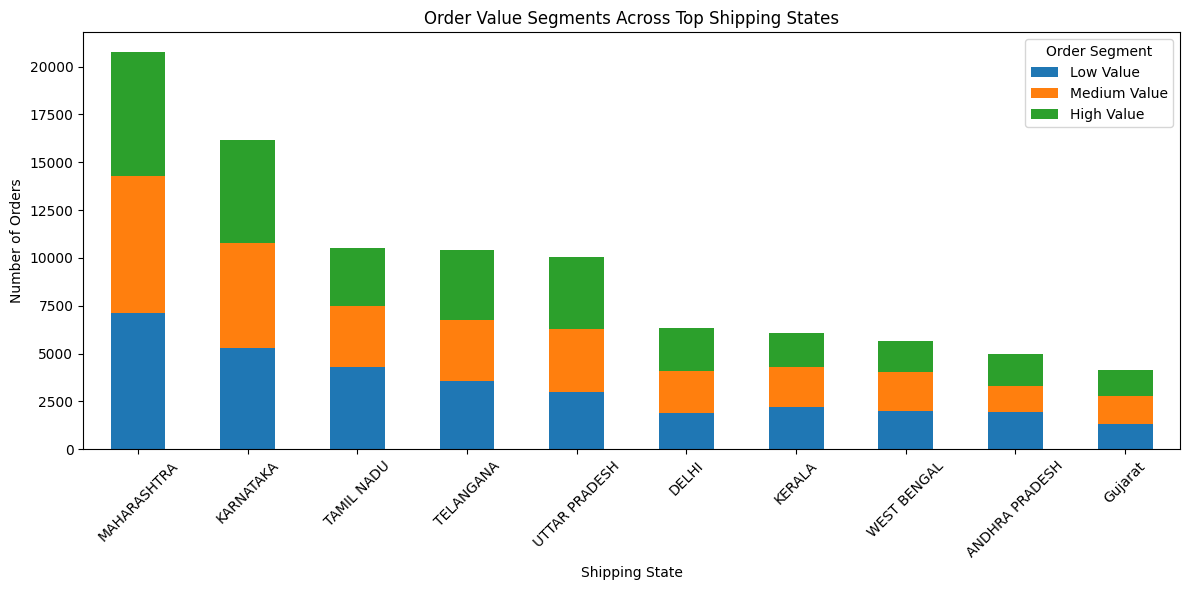

In [200]:
top_segment_states = (
    state_segment_counts
    .sum(axis=1)
    .sort_values(ascending=False)
    .head(10)
    .index
)

state_segment_counts.loc[top_segment_states].plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Order Value Segments Across Top Shipping States")
plt.xlabel("Shipping State")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 3.177 Overall Order Segment Comparison

The total number of low-, medium-, and high-value orders is compared
to understand the overall distribution of order-value behavior.

In [201]:
overall_segment_counts = (
    order_segments
    .value_counts()
    .sort_index()
)

overall_segment_counts

,count
Amount,
Low Value,40301
Medium Value,39865
High Value,40063


## 3.178 Dominant Order Segment

The order-value segment containing the largest number of orders is
identified to determine the dominant behavioral group in the dataset.

In [202]:
dominant_order_segment = overall_segment_counts.idxmax()
dominant_order_segment_count = overall_segment_counts.max()

print("Dominant order segment:", dominant_order_segment)
print("Number of orders:", dominant_order_segment_count)

Dominant order segment: Low Value
Number of orders: 40301


## 3.179 Segmentation Insights

The segmentation analysis groups orders according to their recorded
sales value and examines their distribution across geographical markets.

The analysis helps identify the dominant order-value segment and the
shipping states associated with higher-value orders. These findings
provide a basic behavioral and geographical view of the transaction
data and can support market prioritization and order-value analysis.

## 3.180 Customer Segmentation Analysis Conclusion

A direct customer-level segmentation could not be performed because
the dataset does not contain a dedicated Customer ID or customer-level
identifier.

Therefore, the analysis uses Order ID to perform order-level behavioral
segmentation based on recorded sales value and combines this with
shipping-state information for geographical analysis.

This approach provides useful insight into order-value behavior and
regional distribution while remaining consistent with the variables
available in the dataset.

## 3.181 Overall Business Performance Summary

The major performance indicators generated during the analysis are
summarized to provide an overall view of the transaction dataset.

The summary includes the total number of records, unique orders,
total quantity, and total recorded sales amount.

In [203]:
total_records = len(df_clean)
total_unique_orders = df_clean["Order ID"].nunique()
total_quantity = df_clean["Qty"].sum()
total_recorded_sales = df_clean["Amount"].sum()

print("Total records:", total_records)
print("Unique orders:", total_unique_orders)
print("Total quantity:", total_quantity)
print("Total recorded sales:", round(total_recorded_sales, 2))

Total records: 128808
Unique orders: 120229
Total quantity: 116496
Total recorded sales: 78496786.39


## 3.182 Key Product Insights

The strongest product categories and sizes are identified using
the results from quantity and recorded sales analysis.

This helps highlight products that may require greater attention
in inventory planning and sales strategy.

In [204]:
print("Highest-volume category:", highest_volume_category)
print("Highest-sales category:", highest_sales_category)

print("Highest-volume size:", highest_volume_size)
print("Highest-sales size:", highest_sales_size)

Highest-volume category: T-shirt
Highest-sales category: T-shirt
Highest-volume size: M
Highest-sales size: M


## 3.183 Key Geographical Insights

The leading geographical markets are identified using state-level
and city-level order and recorded sales results.

These findings can help identify regions that may require greater
business attention.

In [205]:
print("Top state by order records:", state_order_counts.idxmax())
print("Top state by recorded sales:", state_sales.idxmax())

print("Top city by order records:", city_order_counts.idxmax())
print("Top city by recorded sales:", city_sales.idxmax())

Top state by order records: MAHARASHTRA
Top state by recorded sales: MAHARASHTRA
Top city by order records: BENGALURU
Top city by recorded sales: BENGALURU


## 3.184 Key Fulfillment Insights

The fulfillment analysis is used to identify the most commonly used
fulfillment method and the fulfillment method associated with the
highest recorded sales amount.

In [206]:
print("Most common fulfillment method:", most_common_fulfilment)
print("Highest-sales fulfillment method:", highest_fulfilment_sales)

Most common fulfillment method: Amazon
Highest-sales fulfillment method: Amazon


## 3.185 Key Courier Insights

The courier analysis is used to identify the most common courier
status and the courier status associated with the highest recorded
sales amount.

In [207]:
print("Most common courier status:", most_common_courier_status)
print("Highest-sales courier status:", highest_courier_sales_status)

Most common courier status: Shipped
Highest-sales courier status: Shipped


## 3.186 Key B2B Insights

The B2B analysis is used to identify the B2B status associated with
the highest recorded sales amount and compare the contribution of
B2B and non-B2B transactions.

In [208]:
print("Highest-sales B2B status:", highest_b2b_sales_status)
print("Recorded sales:", round(highest_b2b_sales, 2))

Highest-sales B2B status: False
Recorded sales: 77905565.6


## 3.187 Key Order-Value Segmentation Insights

The order-value segmentation is used to identify the dominant
behavioral segment and the geographical market with the greatest
number of high-value orders.

In [209]:
print("Dominant order segment:", dominant_order_segment)
print(
    "State with most high-value orders:",
    highest_high_value_state
)

Dominant order segment: Low Value
State with most high-value orders: MAHARASHTRA


## 3.188 Business Recommendations

Based on the analysis performed on the available transaction data,
the following recommendations can be considered:

1. Inventory planning should give greater attention to high-volume
   product categories and sizes identified during the analysis.

2. Sales strategies can prioritize geographical markets that show
   higher order volume or recorded sales.

3. Fulfillment performance should be monitored for the fulfillment
   methods handling a large share of orders and recorded sales.

4. Courier status patterns should be monitored to identify potential
   areas for improvement in order delivery operations.

5. High-value order segments can be given additional attention through
   targeted sales and retention strategies.

6. B2B and non-B2B transaction patterns can be compared regularly to
   identify opportunities for business-focused sales strategies.

7. Future analysis would benefit from a dedicated Customer ID so that
   true customer-level segmentation, repeat-purchase analysis, and
   customer lifetime behavior can be performed.

## 3.189 Final Project Conclusion

The data analysis examined sales, order behavior, product performance,
fulfillment, courier status, B2B transactions, geographical
distribution, and order-value segmentation.

The analysis identified important patterns in product categories,
product sizes, geographical markets, fulfillment methods, courier
statuses, and order-value segments.

These findings provide a data-driven view of business performance and
can support decisions related to inventory planning, sales strategy,
regional focus, fulfillment operations, and customer/order management.

The analysis is based on the variables available in the dataset.
Because a dedicated Customer ID is not available, the segmentation
component uses Order ID and geographical information rather than
claiming to represent true individual customer behavior.

## 3.190 End of Exploratory Data Analysis

The exploratory data analysis phase is complete.

The dataset has been examined from multiple business perspectives,
and the major findings have been converted into actionable insights
and recommendations.

The next stage will focus on presenting the findings clearly through
the final report and project documentation.

### 3.191 Order Behavioral Profile

Each unique order is represented using measurable behavioral characteristics including total recorded sales, total quantity purchased, and number of product records associated with the order.

These variables provide a transaction-level representation of purchasing behavior and allow orders to be grouped into meaningful behavioral segments.

In [212]:
# Create an order-level behavioral dataset

order_behavior = pd.DataFrame({
    "Order Value": order_sales,
    "Total Quantity": order_quantity,
    "Product Records": order_record_counts
})

order_behavior.head(10)

,Order Value,Total Quantity,Product Records
Order ID,,,
171-0000547-8192359,301.0,1,1
171-0000902-4490745,544.0,1,1
171-0001409-6228339,422.0,1,1
171-0003082-5110755,563.0,1,1
171-0003738-2052324,379.0,1,1
171-0005637-8167567,579.0,1,1
171-0005741-2261112,558.0,1,1
171-0005999-3189913,1115.0,1,1
171-0006482-2020369,368.0,1,1


### 3.192 Behavioral Classification

Orders are classified according to their purchasing behavior using their total quantity and recorded sales value.

The classification helps distinguish orders with relatively low, medium, and high purchasing activity.

In [214]:
# Create quantity-based and value-based behavioral segments

# Use rank to handle repeated quantity values safely
order_behavior["Quantity Segment"] = pd.qcut(
    order_behavior["Total Quantity"].rank(method="first"),
    q=3,
    labels=["Low Quantity", "Medium Quantity", "High Quantity"]
)

# Create value-based segments
order_behavior["Value Segment"] = pd.qcut(
    order_behavior["Order Value"].rank(method="first"),
    q=3,
    labels=["Low Value", "Medium Value", "High Value"]
)

order_behavior.head(10)

,Order Value,Total Quantity,Product Records,Quantity Segment,Value Segment
Order ID,,,,,
171-0000547-8192359,301.0,1,1,Low Quantity,Low Value
171-0000902-4490745,544.0,1,1,Low Quantity,Medium Value
171-0001409-6228339,422.0,1,1,Low Quantity,Low Value
171-0003082-5110755,563.0,1,1,Low Quantity,Medium Value
171-0003738-2052324,379.0,1,1,Low Quantity,Low Value
171-0005637-8167567,579.0,1,1,Low Quantity,Medium Value
171-0005741-2261112,558.0,1,1,Low Quantity,Medium Value
171-0005999-3189913,1115.0,1,1,Low Quantity,High Value
171-0006482-2020369,368.0,1,1,Low Quantity,Low Value


### 3.193 Behavioral Segment Summary

The number of orders in each quantity and value segment is calculated to understand the distribution of purchasing behavior.

In [215]:
behavioral_summary = pd.DataFrame({
    "Quantity Segment": order_behavior["Quantity Segment"].value_counts().sort_index(),
    "Value Segment": order_behavior["Value Segment"].value_counts().sort_index()
})

behavioral_summary

,Quantity Segment,Value Segment
High Quantity,40077.0,NaN
High Value,NaN,40077.0
Low Quantity,40076.0,NaN
Low Value,NaN,40076.0
Medium Quantity,40076.0,NaN
Medium Value,NaN,40076.0


### 3.194 Average Purchasing Behavior by Value Segment

The average order value, quantity purchased, and number of product records are compared across the three value-based segments.

In [216]:
behavior_summary = (
    order_behavior
    .groupby("Value Segment", observed=True)
    .agg(
        Average_Order_Value=("Order Value", "mean"),
        Average_Quantity=("Total Quantity", "mean"),
        Average_Product_Records=("Product Records", "mean"),
        Number_of_Orders=("Order Value", "count")
    )
    .round(2)
)

behavior_summary

,Average_Order_Value,Average_Quantity,Average_Product_Records,Number_of_Orders
Value Segment,,,,
Low Value,299.09,0.78,1.01,40076
Medium Value,610.34,0.97,1.01,40076
High Value,1049.24,1.16,1.19,40077


### 3.195 Behavioral Segment Visualization

A comparison of average order value across behavioral segments is used to identify differences in purchasing intensity.

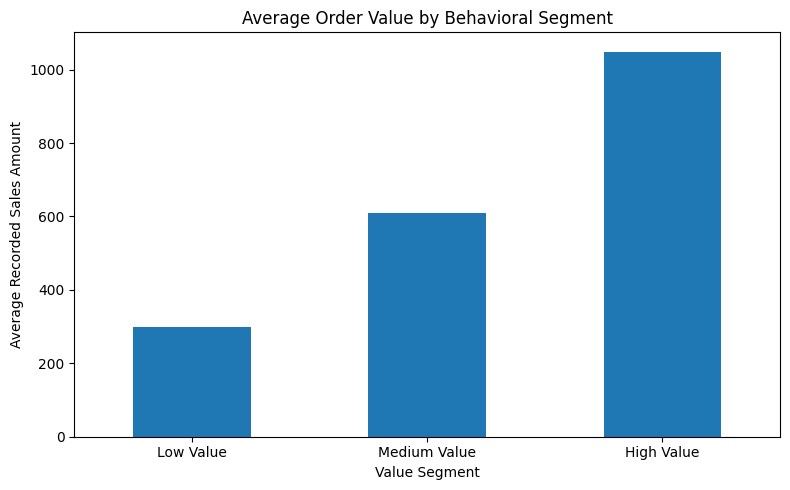

In [217]:
plt.figure(figsize=(8, 5))

behavior_summary["Average_Order_Value"].plot(kind="bar")

plt.title("Average Order Value by Behavioral Segment")
plt.xlabel("Value Segment")
plt.ylabel("Average Recorded Sales Amount")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### 3.196 High-Value Order Distribution by State

The geographical distribution of high-value orders is examined to identify regions contributing a larger number of high-value transactions.

This analysis combines order-value segmentation with shipping-state information to identify important regional markets.

In [218]:
# Combine order-value segments with shipping-state information

order_state_data = df_clean[
    ["Order ID", "ship-state"]
].drop_duplicates()

order_state_data = order_state_data.merge(
    order_behavior[["Value Segment"]],
    left_index=True,
    right_index=True,
    how="left"
)

order_state_data.head(10)

,Order ID,ship-state,Value Segment
0,405-8078784-5731545,MAHARASHTRA,NaN
1,171-9198151-1101146,KARNATAKA,NaN
2,404-0687676-7273146,MAHARASHTRA,NaN
3,403-9615377-8133951,PUDUCHERRY,NaN
4,407-1069790-7240320,TAMIL NADU,NaN
5,404-1490984-4578765,UTTAR PRADESH,NaN
6,408-5748499-6859555,CHANDIGARH,NaN
7,406-7807733-3785945,TELANGANA,NaN
8,407-5443024-5233168,TELANGANA,NaN
9,402-4393761-0311520,TAMIL NADU,NaN


In [220]:
# Create order-level sales values and attach shipping state

order_state_data = (
    df_clean.groupby("Order ID", as_index=False)
    .agg(
        Order_Value=("Amount", "sum"),
        ship_state=("ship-state", "first")
    )
)

# Create the same three order-value segments using quantiles
order_state_data["Value Segment"] = pd.qcut(
    order_state_data["Order_Value"],
    q=3,
    labels=["Low Value", "Medium Value", "High Value"],
    duplicates="drop"
)

order_state_data.head(10)

,Order ID,Order_Value,ship_state,Value Segment
0,171-0000547-8192359,301.0,MAHARASHTRA,Low Value
1,171-0000902-4490745,544.0,WEST BENGAL,Medium Value
2,171-0001409-6228339,422.0,TELANGANA,Low Value
3,171-0003082-5110755,563.0,UTTAR PRADESH,Medium Value
4,171-0003738-2052324,379.0,UTTAR PRADESH,Low Value
5,171-0005637-8167567,579.0,DELHI,Medium Value
6,171-0005741-2261112,558.0,TELANGANA,Medium Value
7,171-0005999-3189913,1115.0,punjab,High Value
8,171-0006482-2020369,368.0,WEST BENGAL,Low Value
9,171-0007176-7613901,352.0,UTTAR PRADESH,Low Value


### 3.197 High-Value Orders by State

High-value orders are grouped by shipping state to identify the regions contributing the greatest number of high-value transactions.

This analysis helps identify geographically important markets for inventory planning and regional sales strategies.

In [221]:
high_value_by_state = (
    order_state_data[order_state_data["Value Segment"] == "High Value"]
    .groupby("ship_state")
    .size()
    .sort_values(ascending=False)
)

high_value_by_state.head(10)

,0
ship_state,
MAHARASHTRA,6476
KARNATAKA,5408
UTTAR PRADESH,3758
TELANGANA,3616
TAMIL NADU,3014
DELHI,2268
KERALA,1785
ANDHRA PRADESH,1649
WEST BENGAL,1616


### 3.198 Identifying the Leading State for High-Value Orders

The state with the highest number of high-value orders is identified to determine the most important regional market within the high-value order segment.

In [222]:
top_high_value_state = high_value_by_state.idxmax()
top_high_value_orders = high_value_by_state.max()

print("Leading state:", top_high_value_state)
print("High-value orders:", top_high_value_orders)

Leading state: MAHARASHTRA
High-value orders: 6476


### 3.199 Visualizing High-Value Orders by State

The top states are visualized using a bar chart to compare the geographical distribution of high-value orders.

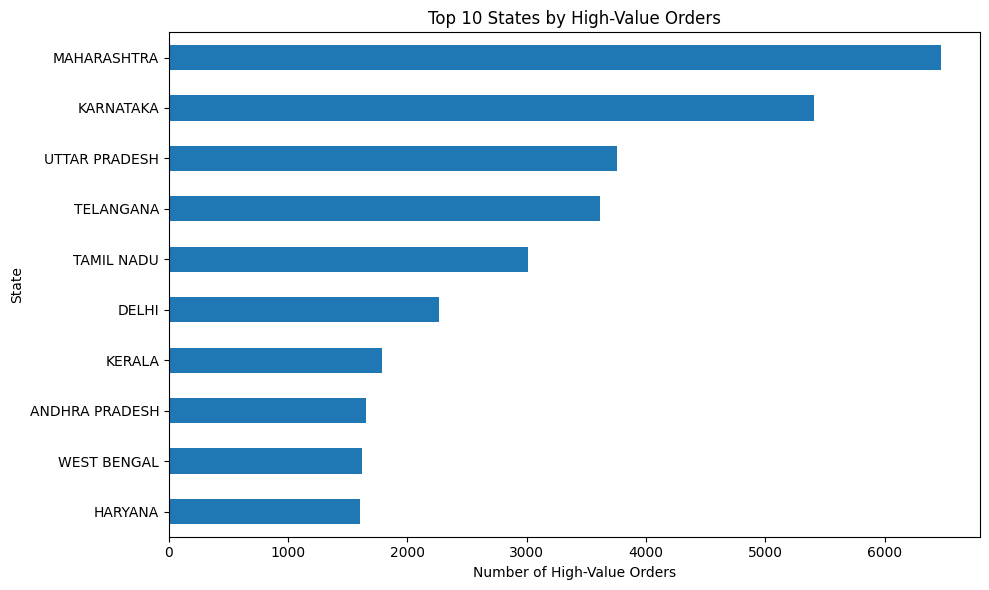

In [223]:
import matplotlib.pyplot as plt

top_states_high_value = high_value_by_state.head(10)

plt.figure(figsize=(10, 6))
top_states_high_value.sort_values().plot(kind="barh")

plt.title("Top 10 States by High-Value Orders")
plt.xlabel("Number of High-Value Orders")
plt.ylabel("State")
plt.tight_layout()
plt.show()

### 3.200 Interpretation of High-Value Order Distribution

The geographical distribution of high-value orders shows which states contribute the greatest number of higher-value transactions. These regions can be considered when planning inventory allocation, regional promotions, and sales strategies.

In [224]:
print("Top 10 states by high-value orders:")
print(top_states_high_value)

Top 10 states by high-value orders:
ship_state
MAHARASHTRA       6476
KARNATAKA         5408
UTTAR PRADESH     3758
TELANGANA         3616
TAMIL NADU        3014
DELHI             2268
KERALA            1785
ANDHRA PRADESH    1649
WEST BENGAL       1616
HARYANA           1599
dtype: int64


### 3.201 Key Business Findings

The analysis identified the major patterns in the Amazon sales dataset. T-shirts were the strongest product category, while size L recorded the highest order volume and quantity and size M generated the highest recorded sales.

Amazon fulfilment handled the majority of transactions, while merchant fulfilment showed a higher cancellation rate. Shipped orders were the dominant courier status.

Maharashtra was the leading state by order records, quantity, and recorded sales, while Bengaluru was the leading city by order records and recorded sales.

High-value orders had a substantially higher average recorded value than low- and medium-value orders. B2B transactions represented a small share of records but had a higher average recorded sales value than non-B2B transactions.

Individual customer-level segmentation could not be performed because the dataset does not contain a dedicated Customer ID.

### 3.202 Business Recommendations

Based on the analysis, inventory planning should prioritize high-volume product categories such as T-shirts and Shirts and give appropriate attention to high-demand sizes such as L and M.

Regional demand should be considered when allocating inventory, particularly in Maharashtra and other high-performing states.

Merchant fulfilment should be monitored closely because its observed cancellation rate was higher than Amazon fulfilment. Cancelled and unshipped orders should also be monitored to identify operational issues.

High-value order segments can be used for targeted sales strategies, while individual customer targeting should not be claimed without a dedicated customer identifier.

B2B transactions should be monitored separately because their average recorded sales value was higher than non-B2B transactions. Future datasets should include a dedicated Customer ID to enable accurate customer segmentation and retention analysis.

### 3.203 Limitations of the Analysis

The analysis has several limitations based on the available dataset.

1. The dataset does not contain a dedicated Customer ID, so individual customer segmentation could not be performed.
2. A significant number of date values were missing, which limits the completeness of time-based analysis.
3. Some Amount values were missing and were retained after investigation.
4. The dataset contains sales transaction values but does not provide complete cost, profit, or margin information.
5. The geographical data is predominantly India-based, limiting international comparison.

### 3.204 Conclusion

The Amazon sales data analysis provided a comprehensive examination of sales performance, product demand, fulfilment methods, courier status, B2B transactions, geographical distribution, and order-value behaviour.

The analysis identified T-shirts as the leading product category, L as the highest-volume size, M as the highest-sales size, Amazon as the dominant fulfilment method, Maharashtra as the leading state, and Bengaluru as the leading city.

Overall, the analysis converts the raw Amazon sales data into actionable business insights that can support improved sales planning, inventory management, fulfilment operations, regional strategies, and customer service.

## 3. Initial Dataset Inspection

The dataset is inspected initially to understand its structure and the type of
information contained in each record.

The first few rows are displayed to obtain an initial understanding of the data.

In [225]:
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Courier Status,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B,fulfilled-by,New,PendingS
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,T-shirt,S,On the Way,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,False,Easy Ship,NaN,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,Shirt,3XL,Shipped,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,False,Easy Ship,NaN,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Shirt,XL,Shipped,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,True,NaN,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,Blazzer,L,On the Way,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,False,Easy Ship,NaN,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Trousers,3XL,Shipped,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,False,NaN,NaN,NaN


## 4. Dataset Dimensions

The dimensions of the dataset are examined to determine the total number of
records and variables available for analysis.

In [226]:
df.shape

(128976, 21)

## 5. Dataset Columns

The column names are examined to identify the variables available in the dataset.

These variables represent information related to orders, products, fulfillment,
sales amount, shipping location, and business transactions.

In [227]:
df.columns

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel',
       'ship-service-level', 'Category', 'Size', 'Courier Status', 'Qty',
       'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code',
       'ship-country', 'B2B', 'fulfilled-by', 'New', 'PendingS'],
      dtype='object')

## 6. Data Types

The data types of all columns are examined to understand how Python is interpreting
each variable.

Checking data types is important because different types of analysis require
different data formats.

In [228]:
df.dtypes

,0
index,int64
Order ID,object
Date,object
Status,object
Fulfilment,object
Sales Channel,object
ship-service-level,object
Category,object
Size,object
Courier Status,object


## 7. Dataset Information

The overall information about the dataset is examined, including the number of
non-null values and the data type of each column.

This step helps identify potential data quality issues that may need to be
addressed during the data cleaning stage.

In [229]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128976 entries, 0 to 128975
Data columns (total 21 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128976 non-null  int64  
 1   Order ID            128976 non-null  object 
 2   Date                128976 non-null  object 
 3   Status              128976 non-null  object 
 4   Fulfilment          128976 non-null  object 
 5   Sales Channel       128976 non-null  object 
 6   ship-service-level  128976 non-null  object 
 7   Category            128976 non-null  object 
 8   Size                128976 non-null  object 
 9   Courier Status      128976 non-null  object 
 10  Qty                 128976 non-null  int64  
 11  currency            121176 non-null  object 
 12  Amount              121176 non-null  float64
 13  ship-city           128941 non-null  object 
 14  ship-state          128941 non-null  object 
 15  ship-postal-code    128941 non-nul

## 8. Descriptive Statistics

Descriptive statistics are calculated for the numerical variables in the dataset.

This provides an initial understanding of the distribution, central tendency,
and range of numerical values such as quantity and order amount.

In [230]:
df.describe()

,index,Qty,Amount,ship-postal-code,New,PendingS
count,128976.000000,128976.000000,121176.000000,128941.000000,0.0,0.0
mean,64486.130427,0.904401,648.562176,463945.677744,NaN,NaN
std,37232.897832,0.313368,281.185041,191458.488954,NaN,NaN
min,0.000000,0.000000,0.000000,110001.000000,NaN,NaN
25%,32242.750000,1.000000,449.000000,382421.000000,NaN,NaN
50%,64486.500000,1.000000,605.000000,500033.000000,NaN,NaN
75%,96730.250000,1.000000,788.000000,600024.000000,NaN,NaN
max,128974.000000,15.000000,5584.000000,989898.000000,NaN,NaN


## 9. Missing Value Analysis

The number of missing values in each column is examined to identify incomplete
data.

This analysis is performed before data cleaning so that appropriate methods can
be selected for handling missing information.

In [231]:
df.isnull().sum()

,0
index,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Category,0
Size,0
Courier Status,0


## 10. Duplicate Record Analysis

The dataset is checked for completely duplicated records.

Identifying duplicate records is an important part of data quality assessment
and will be addressed during the data cleaning stage.

In [232]:
df.duplicated().sum()

np.int64(168)

## 11. Order Status Analysis

The distribution of order statuses is examined to understand the different
stages and outcomes of orders in the dataset.

This initial inspection will support the detailed fulfillment and order
performance analysis later in the project.

In [233]:
df["Status"].value_counts()

,count
Status,
Shipped,77815
Shipped - Delivered to Buyer,28756
Cancelled,18334
Shipped - Returned to Seller,1954
Shipped - Picked Up,973
Pending,658
Pending - Waiting for Pick Up,281
Shipped - Returning to Seller,145
Shipped - Out for Delivery,35


## 12. Fulfillment Analysis

The distribution of orders across different fulfillment methods is examined.

This provides an initial understanding of how orders are fulfilled and will
be used for a more detailed fulfillment performance analysis later.

In [234]:
df["Fulfilment"].value_counts()

,count
Fulfilment,
Amazon,89713
Merchant,39263


## 13. Product Category Analysis

The distribution of products across different categories is examined.

This provides an initial view of the product mix and will support the detailed
product performance analysis in later stages.

In [235]:
df["Category"].value_counts()

,count
Category,
T-shirt,50292
Shirt,49877
Blazzer,15500
Trousers,10616
Perfume,1157
Wallet,926
Socks,440
Shoes,165
Watch,3


## 14. Product Size Analysis

The distribution of product sizes is examined to understand the availability
and frequency of different sizes within the dataset.

Size-level patterns will be investigated further during product analysis.

In [236]:
df["Size"].value_counts()

,count
Size,
M,22373
L,21807
XL,20549
XXL,17806
S,16776
3XL,14643
XS,11056
Free,2251
6XL,738


## 15. Courier Status Analysis

The distribution of courier statuses is examined to understand the current
shipping and delivery-related states represented in the dataset.

This information will contribute to the fulfillment analysis.

In [237]:
df["Courier Status"].value_counts()

,count
Courier Status,
Shipped,109486
On the Way,6870
Unshipped,6680
Cancelled,5940


## 16. B2B Transaction Analysis

The dataset is examined to identify the distribution of Business-to-Business
(B2B) and non-B2B transactions.

This information will later support the customer and business transaction analysis.

In [238]:
df["B2B"].value_counts()

,count
B2B,
False,128104
True,872


## 17. Unique Value Inspection

The unique values in selected categorical variables are examined to understand
the different categories represented in the dataset.

This helps verify the consistency of categorical data before detailed analysis
and cleaning.

In [239]:
df["Fulfilment"].unique()

array(['Merchant', 'Amazon'], dtype=object)

In [240]:
df["B2B"].unique()

array([False,  True])

In [241]:
df["Category"].unique()

array(['T-shirt', 'Shirt', 'Blazzer', 'Trousers', 'Perfume', 'Socks',
       'Shoes', 'Wallet', 'Watch'], dtype=object)

In [242]:
df["Date"].head()

,Date
0,04-30-22
1,04-30-22
2,04-30-22
3,04-30-22
4,04-30-22


## 18. Date Range Analysis

The earliest and latest dates in the dataset are identified to determine the
time period covered by the available sales records.

This time range will be important for analyzing sales trends over time.

In [243]:
print("Start Date:", df["Date"].min())
print("End Date:", df["Date"].max())

Start Date: 03-31-22
End Date: 06-29-22


## 19. Sales Amount Overview

The descriptive statistics of the Amount variable are examined to obtain an
initial understanding of the sales values recorded in the dataset.

A detailed sales and revenue analysis will be performed after the data has
been cleaned.

In [244]:
df["Amount"].describe()

,Amount
count,121176.000000
mean,648.562176
std,281.185041
min,0.000000
25%,449.000000
50%,605.000000
75%,788.000000
max,5584.000000


## 20. Quantity Overview

The descriptive statistics of the Quantity variable are examined to understand
the distribution of quantities recorded in the sales transactions.

A detailed quantity analysis will be performed during the product analysis stage.

In [245]:
df["Qty"].describe()

,Qty
count,128976.000000
mean,0.904401
std,0.313368
min,0.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,15.000000
